## Modelado computacional, simulación y optimización. Proyecto 5: OpenFACADES

Nicolás Vives Vicente

Carlos Sanchiz Pérez

### Dependencias

Cargamos las librerías necesarias:

In [ ]:
import os
import sys

from huggingface_hub import snapshot_download

import matplotlib.pyplot as plt

import warnings

import geopandas as gpd

import seaborn as sns
import pandas as pd
import numpy as np
import json
import torch
from transformers import AutoModel, AutoTokenizer
from pathlib import Path

import shutil
from google.colab import files
from google.colab import drive

### Inferencia

from PIL import Image
from IPython.display import display

### Open FACADES

In [ ]:
# clonamos los repositorios
if not os.path.exists('OpenFACADES'):
    !git clone https://github.com/seshing/OpenFACADES.git
else:
    print("OpenFACADES ya estaba clonado.")

if not os.path.exists('InternVL'):
    !git clone https://github.com/OpenGVLab/InternVL.git
else:
    print("InternVL ya estaba clonado.")

# instalación de dependencias
!pip install -q -e ./OpenFACADES
!pip install -q -r ./OpenFACADES/requirements.txt

# corrección para evitar conflictos de dependencias
!sed -i '/^mmcv-full/d' ./InternVL/requirements/segmentation.txt
!pip install -q -r ./InternVL/requirements.txt

# librerías complementarias necesarias para el análisis geoespacial y visual
!pip install -q decord huggingface_hub protobuf geopandas matplotlib seaborn overturemaps transformers torch torchvision

%cd /content
snapshot_download(repo_id="seshing/openfacades-internvl3-2b", local_dir="model/openfacades-internvl3-2b")

# añadimos la carpeta del framework al PATH para que Python encuentre sus módulos internos
sys.path.append(os.path.abspath('OpenFACADES'))

warnings.filterwarnings('ignore') # evita mensajes de advertencia al final

# creación de carpetas para no mezclar los datos de Toledo y Madrid
BASE_DIR = 'proyecto_mcso_datos'
ZONAS = ['madrid_historico', 'paris_haussmann', 'ny_manhattan', 'amsterdam_centro']
CARPETAS_INTERNAS = ['01_footprints', '02_images', '03_results']

for zona in ZONAS:
    for carpeta in CARPETAS_INTERNAS:
        ruta = os.path.join(BASE_DIR, zona, carpeta)
        os.makedirs(ruta, exist_ok=True)

from openfacades.vlm import building_vlm

from zensvi.download import MLYDownloader
from openfacades.streetview import bbox_to_geojson, process_metadata
from openfacades.streetview import geo_aov_calculator, filter_img_by_aov
from openfacades.detection import filter_img_by_features
from openfacades.detection import GroundingDinoDetector

from openfacades.footprint import BuildingDataDownloader

print('Carga completada')

OpenFACADES ya estaba clonado.
InternVL ya estaba clonado.
  Preparing metadata (setup.py) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.6 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
timezonefinder 8.2.4 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
zensvi 1.4.7 requires transformers>=4.40.0, but you have transformers 4.37.2 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-pytho

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Carga completada


In [ ]:
# extracción de datos espaciales y filtro geométrico

# definimos las cajas delimitadoras (BBOX) y sus respectivos EPSG métricos locales
regiones = {
    'madrid_historico': {
        'bbox': [-3.7140, 40.4110, -3.7040, 40.4170],
        'epsg': 32630  # UTM Zona 30N (España)
    },
    'paris_haussmann': {
        'bbox': [2.3250, 48.8700, 2.3350, 48.8750],
        'epsg': 32631  # UTM Zona 31N (Francia)
    },
    'ny_manhattan': {
        'bbox': [-74.0040, 40.7200, -73.9950, 40.7260],
        'epsg': 32618  # UTM Zona 18N (Nueva York)
    },
    'amsterdam_centro': {
        'bbox': [4.8840, 52.3680, 4.8920, 52.3740],
        'epsg': 32631  # UTM Zona 31N (Países Bajos)
    }
}

# parámetros del filtro geométrico (en metros cuadrados)
AREA_MINIMA = 30    # descartar kioskos, marquesinas, casetas
AREA_MAXIMA = 15000  # descartar macro-estructuras (estadios, grandes naves)

edificios_por_zona = {}
BASE_DIR = 'proyecto_mcso_datos'

for zona, info in regiones.items():
    print(f"--- Procesando: {zona.replace('_', ' ').upper()} ---")

    bbox = info['bbox']
    epsg_local = info['epsg']

    # Paso A: descarga bruta desde Overture Maps
    downloader_overture = BuildingDataDownloader(source="overture")
    gdf_bruto = downloader_overture.download_buildings(bbox)
    total_inicial = len(gdf_bruto)
    print(f" > Edificios detectados inicialmente: {total_inicial}")

    # Paso B: transformación a CRS métrico local correspondiente
    # Al usar el EPSG específico de cada región se evitan distorsiones geográficas en el cálculo del área
    gdf_metrico = gdf_bruto.to_crs(epsg = epsg_local)

    # Paso C: cálculo de área y aplicación del filtro
    gdf_bruto['area_m2'] = gdf_metrico.geometry.area

    gdf_filtrado = gdf_bruto[
        (gdf_bruto['area_m2'] >= AREA_MINIMA) &
        (gdf_bruto['area_m2'] <= AREA_MAXIMA)
    ].copy()

    # por seguridad, descartamos infraestructura subterránea si existe
    if 'underground' in gdf_filtrado.columns:
        gdf_filtrado = gdf_filtrado[gdf_filtrado['underground'] != 'yes']

    total_final = len(gdf_filtrado)
    descartados = total_inicial - total_final
    print(f" > Filtro aplicado: {descartados} estructuras atípicas descartadas.")
    print(f" > Edificios válidos para análisis: {total_final}\n")

    # Paso D: guardar el archivo en su carpeta correspondiente
    ruta_salida = os.path.join(BASE_DIR, zona, '01_footprints', 'footprint.geojson')
    gdf_filtrado.to_file(ruta_salida, driver="GeoJSON")

    edificios_por_zona[zona] = gdf_filtrado


--- Procesando: MADRID HISTORICO ---
Retrieving data from Overture...
1000 buildings retrived from Overture...
 > Edificios detectados inicialmente: 1000
 > Filtro aplicado: 25 estructuras atípicas descartadas.
 > Edificios válidos para análisis: 975

--- Procesando: PARIS HAUSSMANN ---
Retrieving data from Overture...
536 buildings retrived from Overture...
 > Edificios detectados inicialmente: 536
 > Filtro aplicado: 61 estructuras atípicas descartadas.
 > Edificios válidos para análisis: 475

--- Procesando: NY MANHATTAN ---
Retrieving data from Overture...
895 buildings retrived from Overture...
 > Edificios detectados inicialmente: 895
 > Filtro aplicado: 2 estructuras atípicas descartadas.
 > Edificios válidos para análisis: 893

--- Procesando: AMSTERDAM CENTRO ---
Retrieving data from Overture...
1035 buildings retrived from Overture...
 > Edificios detectados inicialmente: 1035
 > Filtro aplicado: 99 estructuras atípicas descartadas.
 > Edificios válidos para análisis: 936



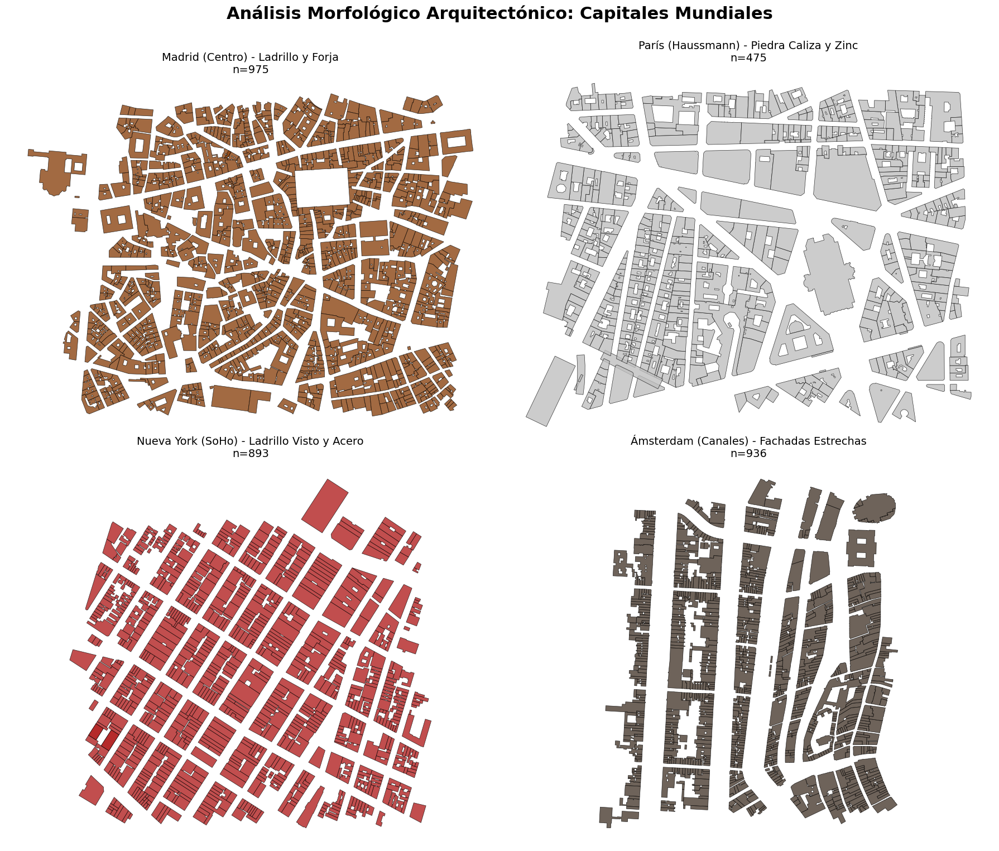

In [ ]:
# creamos una cuadrícula de 2x2 para las 4 ciudddes
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
fig.suptitle('Mapa de las zonas seleccionadas de las capitales mundiales', fontsize=22, fontweight='bold', y=0.95)

# Madrid - Centro Histórico
edificios_por_zona['madrid_historico'].plot(ax=axes[0, 0], color='#8B4513', edgecolor='black', linewidth=0.5, alpha=0.8)
axes[0, 0].set_title(f"Madrid (Centro)\nn={len(edificios_por_zona['madrid_historico'])}", fontsize=14)
axes[0, 0].set_facecolor('#f4f4f4')
axes[0, 0].axis('off')

# París - Boulevard Haussmann
edificios_por_zona['paris_haussmann'].plot(ax=axes[0, 1], color='#C0C0C0', edgecolor='black', linewidth=0.5, alpha=0.8)
axes[0, 1].set_title(f"París (Haussmann)\nn={len(edificios_por_zona['paris_haussmann'])}", fontsize=14)
axes[0, 1].set_facecolor('#f4f4f4')
axes[0, 1].axis('off')

# Nueva York - SoHo (Manhattan)
edificios_por_zona['ny_manhattan'].plot(ax=axes[1, 0], color='#B22222', edgecolor='black', linewidth=0.5, alpha=0.8)
axes[1, 0].set_title(f"Nueva York (SoHo)\nn={len(edificios_por_zona['ny_manhattan'])}", fontsize=14)
axes[1, 0].set_facecolor('#f4f4f4')
axes[1, 0].axis('off')

# Ámsterdam - Canales Centrales
edificios_por_zona['amsterdam_centro'].plot(ax=axes[1, 1], color='#4A3C31', edgecolor='black', linewidth=0.5, alpha=0.8)
axes[1, 1].set_title(f"Ámsterdam (Canales)\nn={len(edificios_por_zona['amsterdam_centro'])}", fontsize=14)
axes[1, 1].set_facecolor('#f4f4f4')
axes[1, 1].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [ ]:
# NO REEJECUTAR

print("Iniciando Módulo de Captura Fotográfica (Motor: Mapillary Oficial)...\n")

# conexión con Mapiliary
mly_api_key = "MLY|26401848886160256|2d4955be5061b68f3afaa1cfecace955"
kwarg = {"image_type": "pano"}
mly_downloader = MLYDownloader(mly_api_key)

# inicialización del detector (GroundingDINO)
detector = GroundingDinoDetector(
    config_path="config/GroundingDINO_SwinT_OGC.py",
    weights_url="https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth"
)

BASE_DIR = 'proyecto_mcso_datos'

# zonas
regiones = {
    'madrid_historico': [-3.7140, 40.4110, -3.7040, 40.4170], # Centro histórico (Alta densidad probada)
    'paris_haussmann': [2.3250, 48.8700, 2.3350, 48.8750],    # Entorno Ópera de París (Piedra caliza)
    'ny_manhattan': [-74.0040, 40.7200, -73.9950, 40.7260],   # SoHo, Nueva York (Ladrillo y acero)
    'amsterdam_centro': [4.8840, 52.3680, 4.8920, 52.3740]    # Canales de Ámsterdam (Fachadas estrechas)
}

ZONAS = list(regiones.keys())

for zona in ZONAS:
    print(f"\n{'='*50}\n PROCESANDO IMÁGENES PARA: {zona.replace('_', ' ').upper()}\n{'='*50}")

    output_data_path = os.path.join(BASE_DIR, zona, '01_footprints')
    output_img_path = os.path.join(BASE_DIR, zona, '02_images')
    images_folder = os.path.join(output_img_path, 'raw_panos')
    os.makedirs(images_folder, exist_ok=True)

    # FASE 1: METADATOS Y ÁNGULO DE VISIÓN (AOV)
    print(" > 1. Descargando metadatos de Mapillary...")

    # creamos un cuadrado simple (BBOX) para evitar atascos matemáticos
    bbox = regiones[zona]
    bbox_path = os.path.join(output_data_path, 'bbox.geojson')
    bbox_to_geojson(bbox).to_file(bbox_path, driver='GeoJSON')

    # descargamos las referencias usando el BBOX simple (Muy rápido)
    mly_downloader.download_svi(
        output_data_path,
        input_shp_file=bbox_path,
        input_place_name="",
        resolution=2048,
        batch_size=500,
        metadata_only=True,
        use_cache=True,
        additional_fields=["camera_type", "captured_at", "computed_compass_angle", "computed_geometry", "geometry", "quality_score"],
        **kwarg
    )

    ruta_csv_metadatos = os.path.join(output_data_path, 'pids_urls.csv')
    if not os.path.exists(ruta_csv_metadatos):
        print(f"Mapillary no reporta imágenes válidas en esta zona.")
        continue

    # procesador original que funciona perfecto con Mapillary
    cleaned_metadata = process_metadata(
        ruta_csv_metadatos,
        os.path.join(output_data_path, 'pids_urls_clean.csv')
    )

    # cálculo de AOV (Radar ampliado a 60m para calles anchas)
    geo_aov_calculator(
        img_metadata=os.path.join(output_data_path, 'pids_urls_clean.csv'),
        json_dir=os.path.join(output_data_path, 'footprint.geojson'),
        buffer=60,
        distance_between_points=2,
        out_dir=os.path.join(output_data_path, 'aov.csv'),
        batch_size=20,
        max_workers=4
    )

    archivo_seleccion = os.path.join(output_data_path, 'pids_urls_select.csv')
    filter_img_by_aov(
        os.path.join(output_data_path, 'aov.csv'),
        os.path.join(output_data_path, 'pids_urls_clean.csv'),
        max_aov=130, min_aov=10, max_image_per_building=5, method='random'
    ).to_csv(archivo_seleccion)

    try:
        df_select = pd.read_csv(archivo_seleccion)
        if len(df_select) == 0:
            print(f" Se han descartado las fotos por mal ángulo frontal.")
            continue
    except pd.errors.EmptyDataError:
        print(f"El archivo de selección se ha quedado vacío.")
        continue

    # FASE 2: DESCARGA DE IMÁGENES PANORÁMICAS
    print(" > 2. Descargando las panorámicas desde Mapillary...")
    mly_downloader.download_svi(
        images_folder,
        path_pid=Path(archivo_seleccion),
        update_pids=False,
        resolution=2048,
        batch_size=1000,
        use_cache=True,
        **kwarg
    )

    # FASE 3: DETECCIÓN Y RECORTE DE FACHADA
    print(" > 3. Recortando fachadas con GroundingDINO...")
    aov_csv = os.path.join(output_data_path, 'aov.csv')

    detector.run_detection(
        geo_aov_csv=aov_csv,
        images_folder=images_folder,
        output_folder=output_img_path,
        box_threshold=0.35,
        adjust_angle=0.05,
        save_annotated_images=False,
        text_prompt="building"
    )

    # FASE 4: FILTRADO DE CALIDAD DE IMAGEN
    print(" > 4. Filtrando recortes defectuosos o borrosos...")
    ruta_individual = os.path.join(output_img_path, 'individual_building')

    if not os.path.exists(ruta_individual) or len(os.listdir(ruta_individual)) == 0:
        print(f"El modelo no logró recortar ninguna fachada válida en {zona}.")
        continue

    suitable_key = filter_img_by_features(
        ruta_individual,
        output_img_path,
        min_file_size=20000,
        min_building_ratio=0.15,
        max_wall_ratio=0.3,
        min_blur=30
    )

    bd_clean_path = os.path.join(output_img_path, 'individual_building_select.csv')
    df = pd.read_csv(os.path.join(output_img_path, 'individual_building.csv'))
    df[df['image_name'].apply(lambda x: x.split('.')[0] in suitable_key)].to_csv(bd_clean_path)

    print(f"Imágenes de {zona} listas y filtradas en: {output_img_path}")

print("\nFase de captura de imágenes completada")

Iniciando Módulo de Captura Fotográfica (Motor: Mapillary Oficial)...

final text_encoder_type: bert-base-uncased

 PROCESANDO IMÁGENES PARA: MADRID HISTORICO
 > 1. Descargando metadatos de Mapillary...
Getting pids...


Loading cache files: 0it [00:00, ?it/s]


[Vector Tiles API] Fetching 4 tiles for images ...


Filtering data: 100%|██████████| 67425/67425 [00:00<00:00, 83009.80it/s]


The panorama IDs have been saved to proyecto_mcso_datos/madrid_historico/01_footprints/mly_pids.csv
The cache directory for tiles has been deleted


...

Processing complete. Results saved in proyecto_mcso_datos/amsterdam_centro/02_images.
 > 4. Filtrando recortes defectuosos o borrosos...
Running Places365 classification...
Using GPU
Using GPU


Processing images: 100%|██████████| 124/124 [00:52<00:00,  2.37it/s]


Running segmentation...
Using GPU


Processing outer batches of size 2000: 100%|██████████| 2/2 [20:24<00:00, 612.20s/it]


Getting image size...
Evaluating bluriness...
3894 images passed all filters from 3962 total images.
Imágenes de amsterdam_centro listas y filtradas en: proyecto_mcso_datos/amsterdam_centro/02_images

Fase de captura de imágenes completada


Para ahorrar tiempo en un futuro, comprimimos el archivo Backup_Fachadas, en formato .zip:

In [ ]:
# SOLO UNA VEZ TRAS EJECUTAR LA CELDA ANTERIOR PARA LA DESCARGA

'''

BASE_DIR = 'proyecto_mcso_datos'
NOMBRE_ZIP = 'Backup_Fachadas'

# comprimir la carpeta entera en un archivo .zip
shutil.make_archive(NOMBRE_ZIP, 'zip', BASE_DIR)

drive.mount('/content/drive')

# copia de seguridad en drive
!cp Backup_Fachadas.zip /content/drive/MyDrive/

# descarga
files.download(f'{NOMBRE_ZIP}.zip')
'''

Mounted at /content/drive


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Inferencia

Cargamos y descomprimimos el archivo comprimido Backup_Fachadas.zip:

In [ ]:
drive.mount('/content/drive')

# copiamos el archivo .zip completo (Nico)
# !cp "/content/drive/Othercomputers/Mi portátil/UA/Ciencia de Datos/Modelado Computacional, Simulación y Optimización/Trabajo Final/Backup_Fachadas.zip" /content/

# Comento lo anterior para utilizarlo yo (Carlos)
!cp "/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Backup_Fachadas.zip" /content/

# descomprimimos el archivo directamente en el entorno local de Colab
!unzip -q /content/Backup_Fachadas.zip -d /content/

print("Done!")

Como tenemos varias imágenes de un mismo edificio, vamos a guardar solamente una de ellas, además, para ahorrar tiempos de carga, vamos a tomar como máximo, 254 imágenes por ciudad.

In [ ]:
BASE_DIR = 'Backup_Fachadas'
ZONAS = ['madrid_historico', 'paris_haussmann', 'ny_manhattan', 'amsterdam_centro']

MAX_FOTOS_POR_CIUDAD = 254

for zona in ZONAS:
    ruta_csv = os.path.join(BASE_DIR, zona, '02_images', 'individual_building_select.csv')
    ruta_salida = os.path.join(BASE_DIR, zona, '02_images', 'individual_building_balanced.csv')

    if not os.path.exists(ruta_csv):
        print(f"No hay CSV para {zona}.")
        continue

    df = pd.read_csv(ruta_csv)
    total_original = len(df)

    if 'building_id' in df.columns:
        df_limpio = df.drop_duplicates(subset=['building_id'], keep='first')
        total_sin_duplicados = len(df_limpio)
    else:
        df_limpio = df
        total_sin_duplicados = len(df_limpio)

    if len(df_limpio) > MAX_FOTOS_POR_CIUDAD:
        df_limpio = df_limpio.sample(n=MAX_FOTOS_POR_CIUDAD, random_state=42)

    total_final = len(df_limpio)

    df_limpio.to_csv(ruta_salida, index=False)

    print(f"{zona.upper()}:")
    print(f"   > Fotos originales: {total_original}")
    print(f"   > Tras quitar edificios repetidos: {total_sin_duplicados}")
    print(f"   > Muestra final: {total_final} fotos\n")

print("Datos balanceados y listos")

MADRID_HISTORICO:
   > Fotos originales: 1163
   > Tras quitar edificios repetidos: 187
   > Muestra final: 187 fotos

PARIS_HAUSSMANN:
   > Fotos originales: 2568
   > Tras quitar edificios repetidos: 254
   > Muestra final: 254 fotos

NY_MANHATTAN:
   > Fotos originales: 339
   > Tras quitar edificios repetidos: 112
   > Muestra final: 112 fotos

AMSTERDAM_CENTRO:
   > Fotos originales: 3894
   > Tras quitar edificios repetidos: 509
   > Muestra final: 254 fotos

Datos balanceados y listos


Cargamos de las imágenes filtradas:

In [ ]:
for zona in ZONAS:
    ruta_csv = os.path.join(BASE_DIR, zona, '02_images', 'individual_building_balanced.csv')
    carpeta_origen = os.path.join(BASE_DIR, zona, '02_images', 'individual_building')
    carpeta_destino = os.path.join(BASE_DIR, zona, '02_images', 'individual_building_balanced')

    os.makedirs(carpeta_destino, exist_ok=True)
    df = pd.read_csv(ruta_csv)

    for img_name in df['image_name']:
        origen_img = os.path.join(carpeta_origen, img_name)
        destino_img = os.path.join(carpeta_destino, img_name)

        shutil.copy2(origen_img, destino_img)

print("Done!")

Definimos los prompts que va leer internvl3:

In [ ]:
question1 = ''' Provide concise labels for each category using the following JSON format. Select appropriate values from the provided options for each category:
				        {
				    "building_type": "(choose one option from: 'apartments', 'house', 'retail', 'office', 'hotel', 'industrial', 'religious', 'education', 'public', 'garage')",
				    "alternate_building_type": "(choose another option from: 'apartments', 'house', 'retail', 'office', 'hotel', 'industrial', 'religious', 'education', 'public', 'garage')",
				    "building_age": "(a 4-digit year indicating the approximate construction date of the building)",
				    "surface_material": "(choose one option from: 'brick', 'wood', 'concrete', 'metal', 'stone', 'glass', 'plaster')",
				    "alternate_surface_material": "(choose another option from: 'brick', 'wood', 'concrete', 'metal', 'stone', 'glass', 'plaster')",
            "floors": "(a numeric value representing the total number of floors)",
				    "construction_material": "(choose one option from: 'brick', 'wood', 'concrete', 'steel', 'other')",
				    "alternate_construction_material": "(choose another option from: 'brick', 'wood', 'concrete', 'steel', 'other')} '''

question2 = ''' Provide concise labels for each category using the following JSON format. Select appropriate values from the provided options for each category:
{
				    "singular_elements": "(choose one or more from: 'balconies', 'bay_windows', 'cornices', 'fire_escapes', 'none')",
            "architectural_style": "(choose one option from: 'classic', 'modern', 'industrial', 'traditional', 'brutalist')",
            "visible_condition": "(choose one option from: 'excellent', 'good', 'fair', 'poor', 'ruin')",
            "glazing_ratio": "(choose one option from: 'low', 'medium', 'high', 'fully_glazed')"}
     '''

question3 = '''Provide concise labels for each category using the following strict JSON format. Select appropriate values from the provided options or use integers from 0 to 10 where requested:
{
    "score_complex": "(an integer from 0 to 10 rating the visual complexity and detail of the facade)",
    "score_original": "(an integer from 0 to 10 rating the originality or uniqueness of the architectural design)",
    "score_boring": "(an integer from 0 to 10 rating how monotonous, dull, or repetitive the facade is)",
    "score_ordered": "(an integer from 0 to 10 rating the symmetry, rhythm, and geometric order of the windows and elements)",
    "score_pleasing": "(an integer from 0 to 10 rating the overall aesthetic appeal and visual harmony of the building)"
}'''

preguntas = [question1, question2, question3]

Definimos todas las rutas donde tenemos las imágenes y las rutas de destino. Vamos ejecutando ciudad por ciudad para no saturar colab.

In [ ]:
# Definimos la ruta donde esta el modelo
ruta_modelo = "seshing/openfacades-internvl3-2b"

# Ajustamos la carpeta que queremos:

ruta_origen_madrid = '/content/Backup_Fachadas/madrid_historico/02_images/individual_building_balanced'
ruta_origen_paris = '/content/Backup_Fachadas/paris_haussmann/02_images/individual_building_balanced'
ruta_origen_manhattan = '/content/Backup_Fachadas/ny_manhattan/02_images/individual_building_balanced'

ruta_destino_madrid1 = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/Madrid/Resultados/Prompt1'
ruta_destino_madrid2 = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/Madrid/Resultados/Prompt2'
ruta_destino_madrid3 = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/Madrid/Resultados/Prompt3'
ruta_destino_paris1 = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/Paris/Resultados/Prompt1'
ruta_destino_paris2 = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/Paris/Resultados/Prompt2'
ruta_destino_paris3 = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/Paris/Resultados/Prompt3'
ruta_destino_manhattan1 = '/content/drive/MyDrive/CienciaDeDatos/ModeladoComputacional/Inferencia/Inferencia/Manhattan/Resultados/Prompt1'
ruta_destino_manhattan2 = '/content/drive/MyDrive/CienciaDeDatos/ModeladoComputacional/Inferencia/Inferencia/Manhattan/Resultados/Prompt2'
ruta_destino_manhattan3 = '/content/drive/MyDrive/CienciaDeDatos/ModeladoComputacional/Inferencia/Inferencia/Manhattan/Resultados/Prompt3'
ruta_destino_amsterdam1 = '/content/drive/MyDrive/CienciaDeDatos/ModeladoComputacional/Inferencia/Inferencia/Amsterdam/Resultados/Prompt1'
ruta_destino_amsterdam2 = '/content/drive/MyDrive/CienciaDeDatos/ModeladoComputacional/Inferencia/Inferencia/Amsterdam/Resultados/Prompt2'
ruta_destino_amsterdam3 = '/content/drive/MyDrive/CienciaDeDatos/ModeladoComputacional/Inferencia/Inferencia/Amsterdam/Resultados/Prompt3'


rutas_destino_madrid = [ruta_destino_madrid1, ruta_destino_madrid2, ruta_destino_madrid3]
rutas_destino_paris = [ruta_destino_paris1, ruta_destino_paris2, ruta_destino_paris3]
rutas_destino_manhattan = [ruta_destino_manhattan1, ruta_destino_manhattan2, ruta_destino_manhattan3]
rutas_destino_manhattan = [ruta_destino_amsterdam1, ruta_destino_amsterdam2, ruta_destino_amsterdam3]


os.makedirs(ruta_destino_manhattan1, exist_ok=True)
os.makedirs(ruta_destino_manhattan2, exist_ok=True)
os.makedirs(ruta_destino_manhattan3, exist_ok=True)

ruta_origen = ruta_origen_manhattan

building_vlm(ruta_modelo,
            preguntas[0],
            single_image=None,
            single_directory=ruta_origen,
            output_directory=ruta_destino_manhattan1,
            csv_input=None)

building_vlm(ruta_modelo,
            preguntas[1],
            single_image=None,
            single_directory=ruta_origen,
            output_directory=ruta_destino_manhattan2,
            csv_input=None)

building_vlm(ruta_modelo,
            preguntas[2],
            single_image=None,
            single_directory=ruta_origen,
            output_directory=ruta_destino_manhattan3,
            csv_input=None)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Processing images: 100%|██████████| 112/112 [19:04<00:00, 10.22s/it]


Responses saved to: /content/drive/MyDrive/CienciaDeDatos/ModeladoComputacional/Inferencia/Inferencia/Manhattan/Resultados/Prompt1/responses.json


/usr/local/lib/python3.12/dist-packages/accelerate/utils/modeling.py:1462: UserWarning: Current model requires 469765632 bytes of buffer for offloaded layers, which seems does not fit any GPU's remaining memory. If you are experiencing a OOM later, please consider using offload_buffers=True.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Processing images: 100%|██████████| 112/112 [13:34<00:00,  7.28s/it]


Responses saved to: /content/drive/MyDrive/CienciaDeDatos/ModeladoComputacional/Inferencia/Inferencia/Manhattan/Resultados/Prompt2/responses.json


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Processing images: 100%|██████████| 112/112 [14:51<00:00,  7.96s/it]

Responses saved to: /content/drive/MyDrive/CienciaDeDatos/ModeladoComputacional/Inferencia/Inferencia/Manhattan/Resultados/Prompt3/responses.json


Cargamos los archivos y tratamos los errores cometimos por internvl3. Por último, los guardamos en formato JSON:

In [ ]:
ruta_destino_madrid1 = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/Madrid/Resultados/Prompt1'
ruta_destino_madrid2 = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/Madrid/Resultados/Prompt2'
ruta_destino_madrid3 = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/Madrid/Resultados/Prompt3'
ruta_destino_paris1 = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/Paris/Resultados/Prompt1'
ruta_destino_paris2 = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/Paris/Resultados/Prompt2'
ruta_destino_paris3 = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/Paris/Resultados/Prompt3'
ruta_destino_amsterdam1 = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/Amsterdam/Resultados/Prompt1'
ruta_destino_amsterdam2 = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/Amsterdam/Resultados/Prompt2'
ruta_destino_amsterdam3 = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/Amsterdam/Resultados/Prompt3'
ruta_destino_manhattan1 = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/Manhattan/Resultados/Prompt1'
ruta_destino_manhattan2 = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/Manhattan/Resultados/Prompt2'
ruta_destino_manhattan3 = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/Manhattan/Resultados/Prompt3'

lista_rutas = [ruta_destino_madrid1, ruta_destino_madrid2, ruta_destino_madrid3, ruta_destino_paris1, ruta_destino_paris2, ruta_destino_paris3,ruta_destino_amsterdam1, ruta_destino_amsterdam2, ruta_destino_amsterdam3, ruta_destino_manhattan1, ruta_destino_manhattan2, ruta_destino_manhattan3]

# Contadores globales para el balance final
global_procesados = 0
global_perfectos = 0
global_reparados = 0
global_insalvables = 0

for ruta in lista_rutas:
    ruta_carpeta = ruta

    # Buscamos los archivos ignorando el de salida limpia
    archivos = [f for f in os.listdir(ruta_carpeta) if f.endswith('.json') and f != 'responses_clean.json']
    if not archivos:
        continue

    nombre_archivo = archivos[0]
    ruta_completa = os.path.join(ruta_carpeta, nombre_archivo)

    with open(ruta_completa, 'r', encoding='utf-8') as f:
        datos_sucios = json.load(f)

    datos_limpios = {}

    for clave, valor in datos_sucios.items():
        global_procesados += 1

        json_limpio = valor.replace("```json", "").replace("```", "").strip()

        # Si el modelo copió bien el formato JSON no salta error, sino se trata
        try:
            datos_limpios[clave] = json.loads(json_limpio)
            global_perfectos += 1
        except json.JSONDecodeError:
            # Eliminar comentarios de línea tipo //
            json_reparado = re.sub(r'//.*', '', json_limpio)

            # Eliminar líneas huérfanas con comillas y comas locas sueltas
            json_reparado = re.sub(r'\n\s*",\s*\n', '\n', json_reparado)

            # Eliminar líneas que contienen únicamente una comilla suelta
            json_reparado = re.sub(r'\n\s*"\s*\n', '\n', json_reparado)

            # Separar campos numéricos con comillas pegados en la misma línea
            json_reparado = re.sub(r'(\d+)"\s+"([a-zA-Z_])', r'\1,\n"\2', json_reparado)

            # Separar número limpio y clave pegados por espacio
            json_reparado = re.sub(r'(\d+)\s+"([a-zA-Z_])', r'\1,\n"\2', json_reparado)

            # Separar propiedades unidas por doble comilla continua sin espacio
            json_reparado = re.sub(r'(\d+)""([a-zA-Z_])', r'\1",\n"\2', json_reparado)

            # Corregir formato "clave: valor
            json_reparado = re.sub(r'"([a-zA-Z_][a-zA-Z0-9_]*):\s*(\d+)"?', r'"\1": \2', json_reparado)

            # Corregir claves numéricas que empiezan por guion bajo en vez de comilla
            json_reparado = re.sub(r'_\s*([a-zA-Z][a-zA-Z0-9_]*)\s*:\s*(\d+)', r'"\1": \2', json_reparado)

            # Añadir comillas a claves estándar que no las tienen
            json_reparado = re.sub(r'([{,]\s*)([a-zA-Z_][a-zA-Z0-9_]*)\s*:', r'\1"\2":', json_reparado)

            # Insertar comas faltantes al final de líneas de propiedades
            json_reparado = re.sub(r'("|\d+|true|false|null)\s*\n\s*"', r'\1,\n"', json_reparado)

            # Eliminar comas duplicadas o colgadas solas entre líneas
            json_reparado = re.sub(r',(\s*,)+', ',', json_reparado)

            # Eliminar comas que hayan quedado huérfanas justo tras abrir llave o corchete
            json_reparado = re.sub(r'([{\[])\s*,', r'\1', json_reparado)

            # Eliminar comas huérfanas antes del cierre de llave o corchete
            json_reparado = re.sub(r',\s*([}\]])', r'\1', json_reparado)

            # Reemplazar comillas simples globales si el modelo las usó de forma incorrecta
            if '"' not in json_reparado and "'" in json_reparado:
                json_reparado = json_reparado.replace("'", '"')

            try:
                datos_limpios[clave] = json.loads(json_reparado, strict=False)
                global_reparados += 1
            except json.JSONDecodeError as e:
                print(f"No conseguimos arreglar el error de la imagen {clave}: {e}")
                global_insalvables += 1

    print(f"\n{os.path.basename(ruta)} revisado")
    # Guardamos los resultados limpios procesados en esta carpeta
    ruta_salida = os.path.join(ruta_carpeta, 'responses_clean.json')
    with open(ruta_salida, 'w', encoding='utf-8') as f:
        json.dump(datos_limpios, f, indent=2, ensure_ascii=False)

print("RESUMEN")
print(f"Total de imágenes analizadas: {global_procesados}")
print(f"Total de respuestas sin fallos:  {global_perfectos}")
print(f"Total de respuestas mal generadas corregidas: {global_reparados}")
print(f"Total de respuestas que no se pueden corregir: {global_insalvables}")
print("-"*60)
total_fallos_detectados = global_reparados + global_insalvables
print(f"CONTEO TOTAL DE FALLOS DETECTADOS:       {total_fallos_detectados}")
if total_fallos_detectados > 0:
    porcentaje_exito = (global_reparados / total_fallos_detectados) * 100
    print(f"Tasa de éxito del motor de reparación:   {porcentaje_exito:.2f}%")

No conseguimos arreglar el error de la imagen pid_784573462191425_bdid_0a17a483-4c51-47cc-a145-ff9e4ce53f8b.png: Expecting property name enclosed in double quotes: line 7 column 15 (char 188)
No conseguimos arreglar el error de la imagen pid_501520427702930_bdid_d245edd6-8fae-48b1-82cd-4851130bedbb.png: Expecting property name enclosed in double quotes: line 7 column 15 (char 188)

Prompt1 revisado

Prompt2 revisado

Prompt3 revisado
No conseguimos arreglar el error de la imagen pid_681559483107846_bdid_8010f49d-eb70-46ee-aae7-2bf5252badf6.png: Expecting property name enclosed in double quotes: line 7 column 15 (char 188)
No conseguimos arreglar el error de la imagen pid_313412094303519_bdid_348ace5b-d050-4f17-b1cb-9ea32ff1ec71.png: Expecting property name enclosed in double quotes: line 7 column 15 (char 188)
No conseguimos arreglar el error de la imagen pid_1553889411668800_bdid_62aac2a0-61ab-4add-a7ac-49a39b5e462b.png: Expecting property name enclosed in double quotes: line 7 column

Vamos a agrupar los prompts por ciudad:

In [ ]:
# Rutas de origen
ruta_destino_madrid1 = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/Madrid/Resultados/Prompt1'
ruta_destino_madrid2 = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/Madrid/Resultados/Prompt2'
ruta_destino_madrid3 = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/Madrid/Resultados/Prompt3'
ruta_destino_paris1 = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/Paris/Resultados/Prompt1'
ruta_destino_paris2 = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/Paris/Resultados/Prompt2'
ruta_destino_paris3 = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/Paris/Resultados/Prompt3'
ruta_destino_amsterdam1 = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/Amsterdam/Resultados/Prompt1'
ruta_destino_amsterdam2 = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/Amsterdam/Resultados/Prompt2'
ruta_destino_amsterdam3 = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/Amsterdam/Resultados/Prompt3'
ruta_destino_manhattan1 = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/Manhattan/Resultados/Prompt1'
ruta_destino_manhattan2 = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/Manhattan/Resultados/Prompt2'
ruta_destino_manhattan3 = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/Manhattan/Resultados/Prompt3'

lista_rutas = [
    ruta_destino_madrid1, ruta_destino_madrid2, ruta_destino_madrid3,
    ruta_destino_paris1, ruta_destino_paris2, ruta_destino_paris3,
    ruta_destino_amsterdam1, ruta_destino_amsterdam2, ruta_destino_amsterdam3,
    ruta_destino_manhattan1, ruta_destino_manhattan2, ruta_destino_manhattan3
]

# Carpeta de destino unificado
ruta_destino_final = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/JSON unidos'

# Crear la carpeta de destino si no existe todavía
os.makedirs(ruta_destino_final, exist_ok=True)

# Diccionario para agrupar los datos internamente
datos_por_ciudad = {}

for ruta in lista_rutas:
    # Extraemos el nombre de la ciudad
    match = re.search(r'/Inferencia/([^/]+)/', ruta)

    ciudad = match.group(1)

    if ciudad not in datos_por_ciudad:
        datos_por_ciudad[ciudad] = {}

    ruta_archivo = os.path.join(ruta, 'responses_clean.json')

    with open(ruta_archivo, 'r', encoding='utf-8') as f:
        try:
            contenido = json.load(f)

            # Recorremos cada imagen del archivo JSON actual
            for nombre_imagen, atributos in contenido.items():
                # Si la imagen no se ha registrado antes en esta ciudad, creamos su espacio vacío
                if nombre_imagen not in datos_por_ciudad[ciudad]:
                    datos_por_ciudad[ciudad][nombre_imagen] = {}

                # Fusionamos los nuevos atributos dentro del diccionario de esa imagen específica
                datos_por_ciudad[ciudad][nombre_imagen].update(atributos)

        except json.JSONDecodeError:
            print(f"Error de lectura (JSON corrupto) en: {ruta_archivo}")


# Grabamos el JSON definitivo para cada una de las ciudades
for ciudad, datos_combinados in datos_por_ciudad.items():
    ruta_salida = os.path.join(ruta_destino_final, f"{ciudad}.json")

    with open(ruta_salida, 'w', encoding='utf-8') as f:
        json.dump(datos_combinados, f, indent=2, ensure_ascii=False)

    print(f"Guardado con éxito: {ciudad}.json en '{ruta_destino_final}' (Total imágenes procesadas: {len(datos_combinados)})")

Guardado con éxito: Madrid.json en '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/JSON unidos' (Total imágenes procesadas: 187)
Guardado con éxito: Paris.json en '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/JSON unidos' (Total imágenes procesadas: 254)
Guardado con éxito: Amsterdam.json en '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/JSON unidos' (Total imágenes procesadas: 254)
Guardado con éxito: Manhattan.json en '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/JSON unidos' (Total imágenes procesadas: 112)


Transormamos los JSON a DataFrame:

In [ ]:
# Ruta directa al archivo de Madrid
ruta_madrid = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/JSON unidos/Madrid.json'

# Cargar el JSON en memoria
with open(ruta_madrid, 'r', encoding='utf-8') as f:
    datos_madrid = json.load(f)

ruta_paris = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/JSON unidos/Paris.json'

# Cargar el JSON en memoria
with open(ruta_paris, 'r', encoding='utf-8') as f:
    datos_paris = json.load(f)

ruta_manhattan = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/JSON unidos/Manhattan.json'

# Cargar el JSON en memoria
with open(ruta_manhattan, 'r', encoding='utf-8') as f:
    datos_manhattan = json.load(f)

ruta_amsterdam = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/JSON unidos/Amsterdam.json'

# Cargar el JSON en memoria
with open(ruta_amsterdam, 'r', encoding='utf-8') as f:
    datos_amsterdam = json.load(f)

import pandas as pd

# Convertimos el diccionario a DataFrame
df_madrid = pd.DataFrame.from_dict(datos_madrid, orient='index')
df_paris = pd.DataFrame.from_dict(datos_paris, orient='index')
df_manhattan = pd.DataFrame.from_dict(datos_manhattan, orient='index')
df_amsterdam = pd.DataFrame.from_dict(datos_amsterdam, orient='index')

Los guardamos en la misma carpeta que los JSON:

In [ ]:
# Convertimos a 'Int64' para eliminar el .0
df_amsterdam['floors'] = df_amsterdam['floors'].astype('Int64')

# Configuración de la descarga/guardado en CSV
ruta_descargas = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/JSON unidos'

# Guardar Amsterdam
ruta_csv_amsterdam = os.path.join(ruta_descargas, 'Amsterdam_limpio.csv')
df_amsterdam.to_csv(ruta_csv_amsterdam, index=True, encoding='utf-8')

# Guardar París
ruta_csv_paris = os.path.join(ruta_descargas, 'Paris_limpio.csv')
df_paris.to_csv(ruta_csv_paris, index=True, encoding='utf-8')

# Guardar Manhattan
ruta_csv_manhattan = os.path.join(ruta_descargas, 'Manhattan_limpio.csv')
df_manhattan.to_csv(ruta_csv_manhattan, index=True, encoding='utf-8')

# Guardar Madrid
ruta_csv_madrid = os.path.join(ruta_descargas, 'España_Madrid.csv')
df_madrid.to_csv(ruta_csv_madrid, index=True, encoding='utf-8')

print("Done!")

Done!


Cargamos los DataFrame:

In [ ]:
ruta_madrid = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/JSON unidos/Madrid_limpio.csv'

df_madrid = pd.read_csv(ruta_madrid)


ruta_amsterdam = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/JSON unidos/Amsterdam_limpio.csv'

df_amsterdam = pd.read_csv(ruta_amsterdam)


ruta_manhattan = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/JSON unidos/Manhattan_limpio.csv'

df_manhattan = pd.read_csv(ruta_manhattan)


ruta_paris = '/content/drive/MyDrive/Colab Notebooks/Modelado Computacional/Trabajo/Inferencia/JSON unidos/Paris_limpio.csv'

df_paris = pd.read_csv(ruta_paris)

Mounted at /content/drive


### Primer análisis

Vamos a analizar la información aportada por el primer prompt:

#### Gráfico para el tipo de edificio (`building_type`)

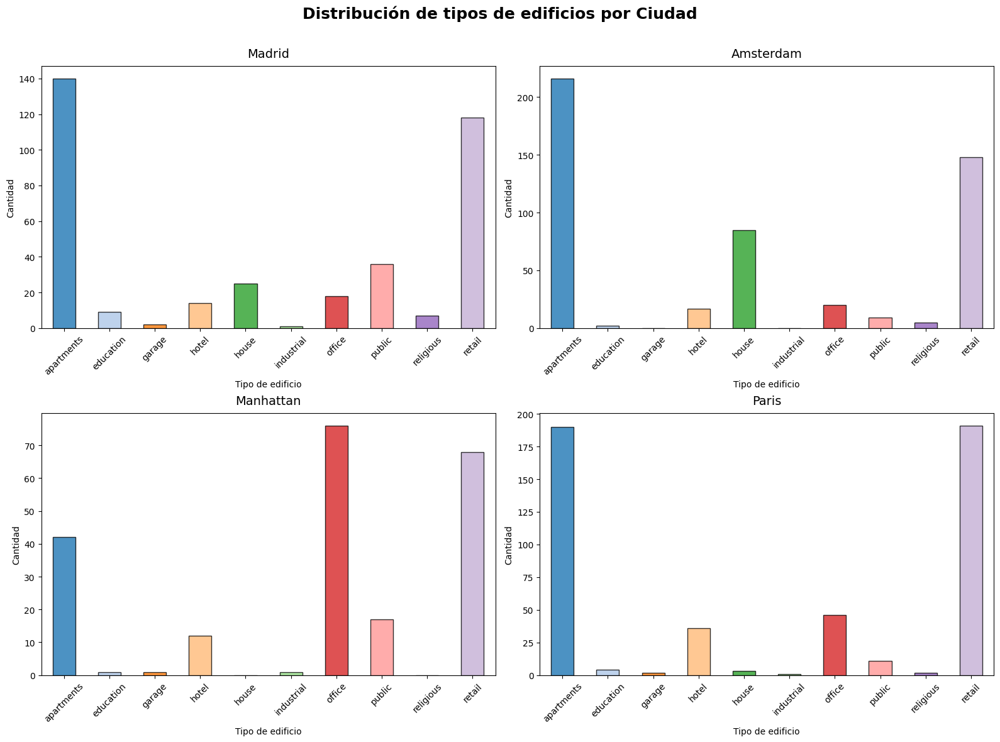

In [ ]:
all_types_madrid = pd.concat([df_madrid['building_type'], df_madrid['alternate_building_type']])
all_types_amsterdam = pd.concat([df_amsterdam['building_type'], df_amsterdam['alternate_building_type']])
all_types_manhattan = pd.concat([df_manhattan['building_type'], df_manhattan['alternate_building_type']])
all_types_paris = pd.concat([df_paris['building_type'], df_paris['alternate_building_type']])

counts_madrid = all_types_madrid.value_counts()
counts_amsterdam = all_types_amsterdam.value_counts()
counts_manhattan = all_types_manhattan.value_counts()
counts_paris = all_types_paris.value_counts()

df_counts = pd.DataFrame({
    "Madrid": counts_madrid,
    "Amsterdam": counts_amsterdam,
    "Manhattan": counts_manhattan,
    "Paris": counts_paris
}).fillna(0)

# ordenar todo el DataFrame alfabéticamente por el índice
df_counts = df_counts.sort_index()

categorias = df_counts.index

cmap = plt.get_cmap('tab20')
colores_por_categoria = {categoria: cmap(i % 20) for i, categoria in enumerate(categorias)}

ciudades = ["Madrid", "Amsterdam", "Manhattan", "Paris"]

# crear la figura y los subgráficos
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
fig.suptitle("Distribución de tipos de edificios por ciudad", fontsize=18, fontweight='bold')
axes = axes.flatten()

for i, ciudad in enumerate(ciudades):

    data_ciudad = df_counts[ciudad]

    colores_barras = [colores_por_categoria[cat] for cat in data_ciudad.index]

    data_ciudad.plot(kind='bar', ax=axes[i], color=colores_barras, edgecolor='black', alpha=0.8)

    # configuraciones de cada subgráfico
    axes[i].set_title(f"{ciudad}", fontsize=14, pad=10)
    axes[i].set_xlabel("Tipo de edificio")
    axes[i].set_ylabel("Cantidad")

    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.subplots_adjust(top=0.90)

plt.show()

#### Antiguedad de los edificios (`building_age`)

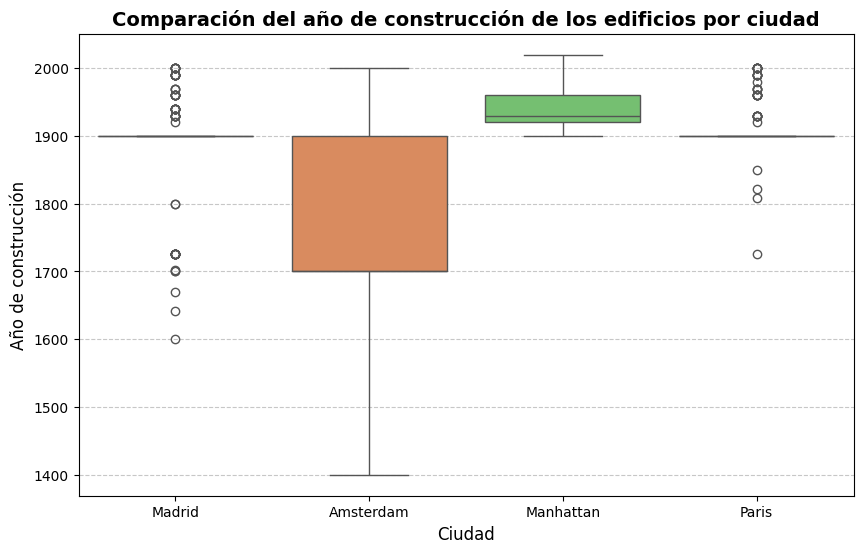

In [ ]:
# columna identificadora a cada dataframe antes de unirlos
df_madrid['city'] = 'Madrid'
df_amsterdam['city'] = 'Amsterdam'
df_manhattan['city'] = 'Manhattan'
df_paris['city'] = 'Paris'

# 4 dataframes en uno solo
df_total = pd.concat([df_madrid, df_amsterdam, df_manhattan, df_paris], ignore_index=True)

# tamaño del gráfico
plt.figure(figsize=(10, 6))

# boxplot
sns.boxplot(x='city', y='building_age', data=df_total, palette='muted')

plt.title('Comparación del año de construcción de los edificios por ciudad', fontsize=14, fontweight='bold')
plt.xlabel('Ciudad', fontsize=12)
plt.ylabel('Año de construcción', fontsize=12)

# gráfico
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Material de la fachada (`surface_material`)

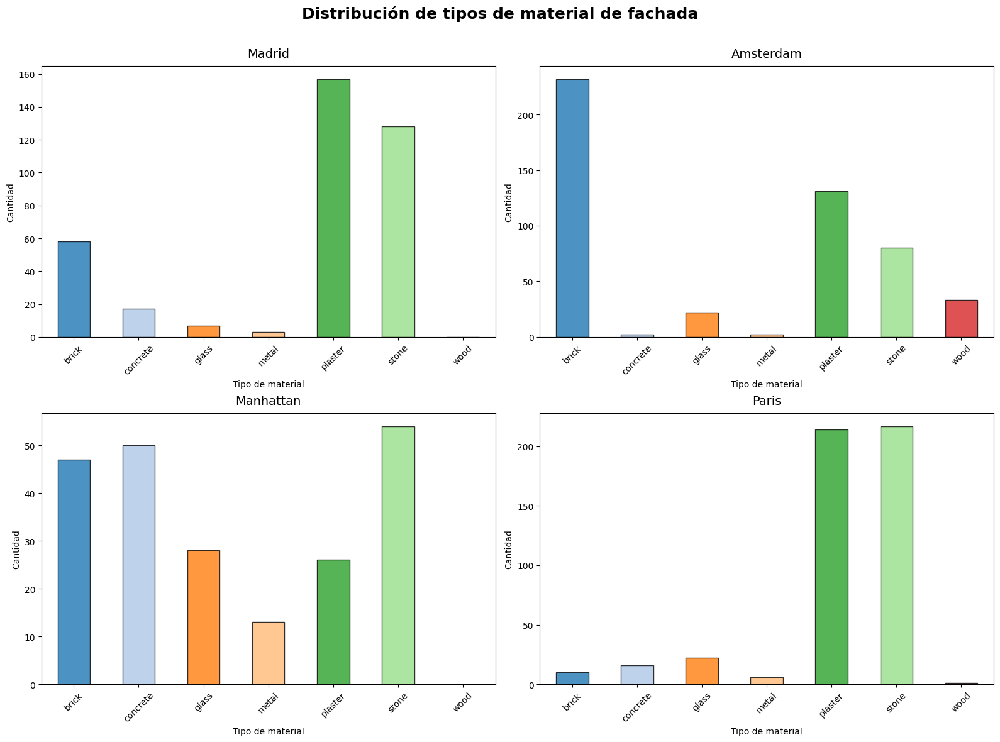

In [ ]:
all_types_madrid = pd.concat([df_madrid['surface_material'], df_madrid['alternate_surface_material']])
all_types_amsterdam = pd.concat([df_amsterdam['surface_material'], df_amsterdam['alternate_surface_material']])
all_types_manhattan = pd.concat([df_manhattan['surface_material'], df_manhattan['alternate_surface_material']])
all_types_paris = pd.concat([df_paris['surface_material'], df_paris['alternate_surface_material']])

counts_madrid = all_types_madrid.value_counts()
counts_amsterdam = all_types_amsterdam.value_counts()
counts_manhattan = all_types_manhattan.value_counts()
counts_paris = all_types_paris.value_counts()

df_counts = pd.DataFrame({
    "Madrid": counts_madrid,
    "Amsterdam": counts_amsterdam,
    "Manhattan": counts_manhattan,
    "Paris": counts_paris
}).fillna(0)

# ordenar todo el DataFrame alfabéticamente por el índice
df_counts = df_counts.sort_index()

categorias = df_counts.index

cmap = plt.get_cmap('tab20')
colores_por_categoria = {categoria: cmap(i % 20) for i, categoria in enumerate(categorias)}

ciudades = ["Madrid", "Amsterdam", "Manhattan", "Paris"]

# crear la figura y los subgráficos
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
fig.suptitle("Distribución de tipos de material de fachada", fontsize=18, fontweight='bold')
axes = axes.flatten()

for i, ciudad in enumerate(ciudades):

    data_ciudad = df_counts[ciudad]

    colores_barras = [colores_por_categoria[cat] for cat in data_ciudad.index]

    data_ciudad.plot(kind='bar', ax=axes[i], color=colores_barras, edgecolor='black', alpha=0.8)

    # configuraciones de cada subgráfico
    axes[i].set_title(f"{ciudad}", fontsize=14, pad=10)
    axes[i].set_xlabel("Tipo de material")
    axes[i].set_ylabel("Cantidad")

    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.subplots_adjust(top=0.90)

plt.show()

#### Gráfico para el número de plantas (`floors`)

/tmp/ipykernel_3333/876435807.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




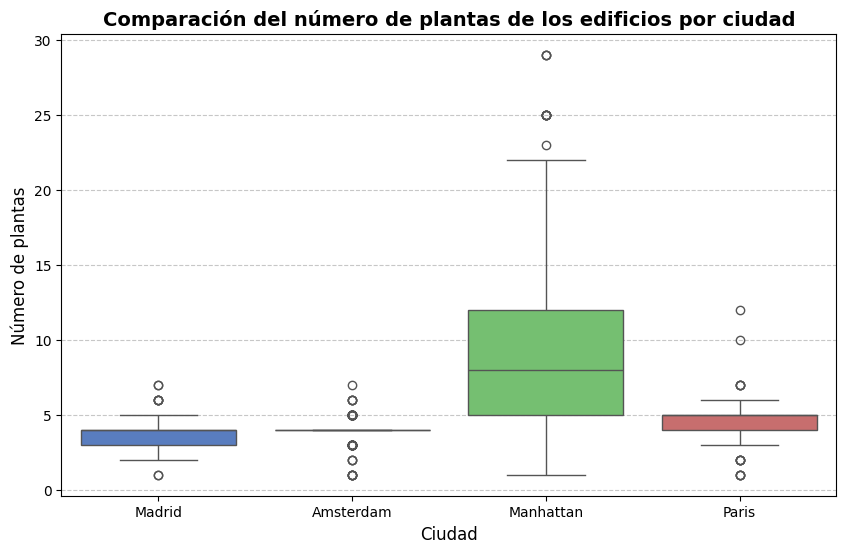

In [ ]:
# 1. Añadir una columna identificadora a cada dataframe antes de unirlos
df_madrid['city'] = 'Madrid'
df_amsterdam['city'] = 'Amsterdam'
df_manhattan['city'] = 'Manhattan'
df_paris['city'] = 'Paris'

# 2. Concatenar los 4 dataframes en uno solo
df_total = pd.concat([df_madrid, df_amsterdam, df_manhattan, df_paris], ignore_index=True)

# 3. Configurar el tamaño del gráfico
plt.figure(figsize=(10, 6))

# 4. Crear el boxplot
sns.boxplot(x='city', y='floors', data=df_total, palette='muted')

# 5. Personalizar etiquetas y título
plt.title('Comparación del número de plantas de los edificios por ciudad', fontsize=14, fontweight='bold')
plt.xlabel('Ciudad', fontsize=12)
plt.ylabel('Número de plantas', fontsize=12)

# 6. Mostrar el gráfico
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Material de construcción (`construction_material`)

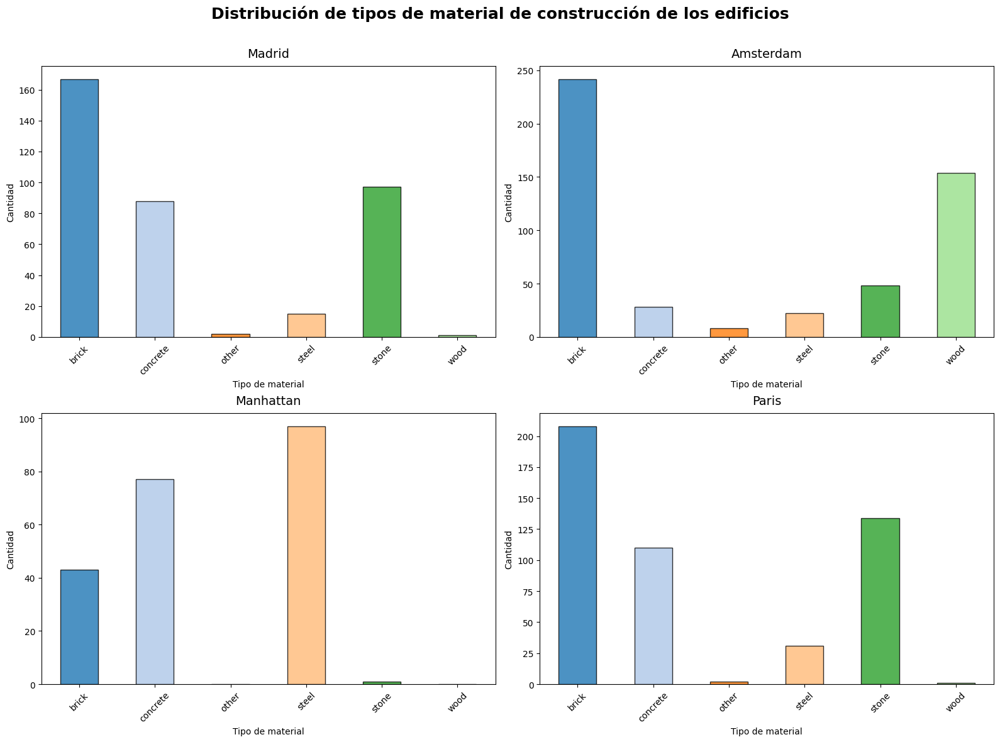

In [ ]:
all_types_madrid = pd.concat([df_madrid['construction_material'], df_madrid['alternate_construction_material']])
all_types_amsterdam = pd.concat([df_amsterdam['construction_material'], df_amsterdam['alternate_construction_material']])
all_types_manhattan = pd.concat([df_manhattan['construction_material'], df_manhattan['alternate_construction_material']])
all_types_paris = pd.concat([df_paris['construction_material'], df_paris['alternate_construction_material']])

counts_madrid = all_types_madrid.value_counts()
counts_amsterdam = all_types_amsterdam.value_counts()
counts_manhattan = all_types_manhattan.value_counts()
counts_paris = all_types_paris.value_counts()

df_counts = pd.DataFrame({
    "Madrid": counts_madrid,
    "Amsterdam": counts_amsterdam,
    "Manhattan": counts_manhattan,
    "Paris": counts_paris
}).fillna(0)

# ordenar todo el DataFrame alfabéticamente por el índice
df_counts = df_counts.sort_index()

categorias = df_counts.index

cmap = plt.get_cmap('tab20')
colores_por_categoria = {categoria: cmap(i % 20) for i, categoria in enumerate(categorias)}

ciudades = ["Madrid", "Amsterdam", "Manhattan", "Paris"]

# crear la figura y los subgráficos
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
fig.suptitle("Distribución de tipos de material de construcción de los edificios", fontsize=18, fontweight='bold')
axes = axes.flatten()

for i, ciudad in enumerate(ciudades):

    data_ciudad = df_counts[ciudad]

    colores_barras = [colores_por_categoria[cat] for cat in data_ciudad.index]

    data_ciudad.plot(kind='bar', ax=axes[i], color=colores_barras, edgecolor='black', alpha=0.8)

    # configuraciones de cada subgráfico
    axes[i].set_title(f"{ciudad}", fontsize=14, pad=10)
    axes[i].set_xlabel("Tipo de material")
    axes[i].set_ylabel("Cantidad")

    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.subplots_adjust(top=0.90)

plt.show()

### Segundo análisis

Vamos a analizar la información aportada por el segundo prompt:

#### Elementos singulares (`singular_elements`)

Primer vamos a hacer un filtrado y nos vamos a quedar solamente con los elementos propuestos en el prompt:

In [ ]:
# valores permitidos
valid_elements = {
    'balconies',
    'bay_windows',
    'cornices',
    'fire_escapes',
    'none'
}

def clean_singular_elements(df, column='singular_elements'):
    def clean_entry(x):
        if pd.isna(x):
            return 'none'

        # convertir a string y normalizar
        x = str(x).lower()

        # separar posibles múltiples valores (por comas u otros separadores)
        tokens = [t.strip() for t in x.replace(';', ',').split(',')]

        # filtrar solo los válidos
        valid_tokens = [t for t in tokens if t in valid_elements and t != 'none']

        # si no hay ninguno válido → 'none'
        if not valid_tokens:
            return 'none'

        # eliminar duplicados y devolver como string limpio
        return ', '.join(sorted(set(valid_tokens)))

    df[column] = df[column].apply(clean_entry)
    return df

# aplicar a todos los dataframes
df_madrid_ordenado = clean_singular_elements(df_madrid)
df_paris_ordenado = clean_singular_elements(df_paris)
df_manhattan_ordenado = clean_singular_elements(df_manhattan)
df_amsterdam_ordenado = clean_singular_elements(df_amsterdam)

In [ ]:
import pandas as pd

# Unir todos los dataframes
df_total = pd.concat(
    [df_madrid_ordenado, df_paris_ordenado, df_manhattan_ordenado, df_amsterdam_ordenado],
    ignore_index=True
)

# Separar los elementos múltiples en filas individuales
df_exploded = df_total.copy()
df_exploded['singular_elements'] = df_exploded['singular_elements'].str.split(', ')
df_exploded = df_exploded.explode('singular_elements')

# Calcular conteos por ciudad y elemento
tabla = (
    df_exploded
    .groupby(['city', 'singular_elements'])
    .size()
    .reset_index(name='count')
)

# Convertir a formato tabla (pivot) con valores absolutos
tabla_pivot = tabla.pivot(
    index='city',
    columns='singular_elements',
    values='count'
).fillna(0).astype(int)

print(tabla_pivot)

singular_elements  balconies  bay_windows  cornices  fire_escapes  none
city                                                                   
Amsterdam                 71            4         7             0   172
Madrid                   143            0         0             0    44
Manhattan                 18            2         3            24    65
Paris                    206            0         0             2    46


#### Estilo arquitectónico (`architectural_style`)

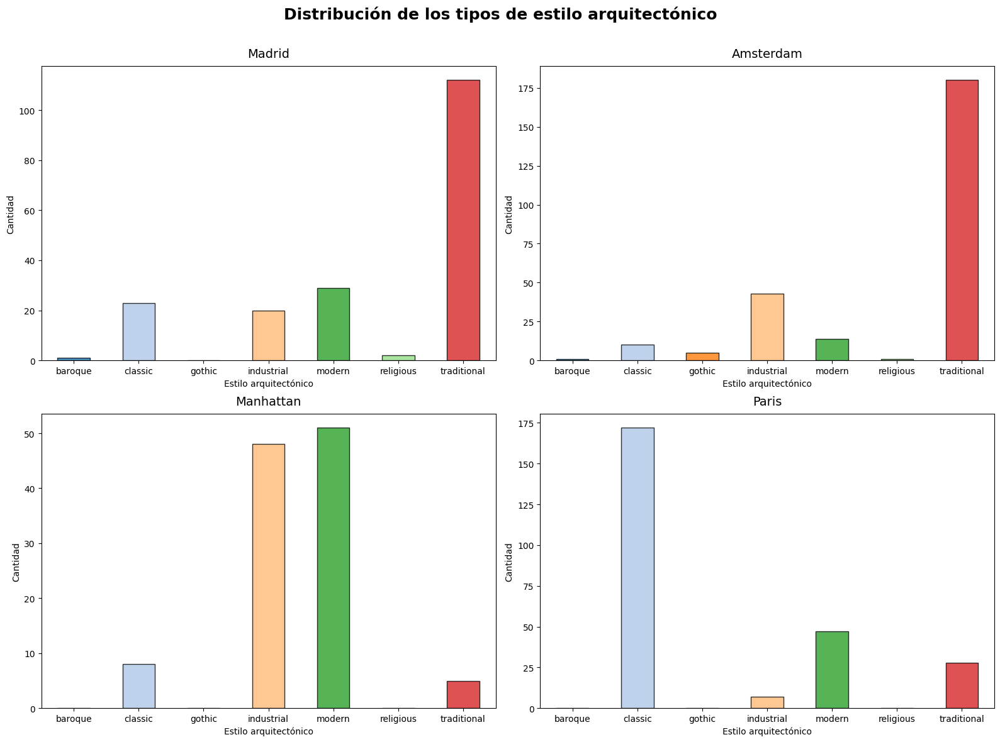

In [ ]:
unificaciones = {
    'classical': 'classic',
    'Gothic' : 'gothic',
    'brick': 'traditional'
}

def limpiar_estilos(serie):
    serie_limpia = serie.str.lower().str.strip()
    serie_limpia = serie_limpia.replace(unificaciones)
    return serie_limpia

df_madrid['architectural_style'] = limpiar_estilos(df_madrid['architectural_style'])
df_amsterdam['architectural_style'] = limpiar_estilos(df_amsterdam['architectural_style'])
df_manhattan['architectural_style'] = limpiar_estilos(df_manhattan['architectural_style'])
df_paris['architectural_style'] = limpiar_estilos(df_paris['architectural_style'])

all_types_madrid = df_madrid['architectural_style']
all_types_amsterdam = df_amsterdam['architectural_style']
all_types_manhattan = df_manhattan['architectural_style']
all_types_paris = df_paris['architectural_style']

counts_madrid = all_types_madrid.value_counts()
counts_amsterdam = all_types_amsterdam.value_counts()
counts_manhattan = all_types_manhattan.value_counts()
counts_paris = all_types_paris.value_counts()

df_counts = pd.DataFrame({
    "Madrid": counts_madrid,
    "Amsterdam": counts_amsterdam,
    "Manhattan": counts_manhattan,
    "Paris": counts_paris
}).fillna(0)

# ordenar todo el DataFrame alfabéticamente por el índice
df_counts = df_counts.sort_index()

categorias = df_counts.index

cmap = plt.get_cmap('tab20')
colores_por_categoria = {categoria: cmap(i % 20) for i, categoria in enumerate(categorias)}

ciudades = ["Madrid", "Amsterdam", "Manhattan", "Paris"]

# crear la figura y los subgráficos
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
fig.suptitle("Distribución de los tipos de estilo arquitectónico", fontsize=18, fontweight='bold')
axes = axes.flatten()

for i, ciudad in enumerate(ciudades):

    data_ciudad = df_counts[ciudad]

    colores_barras = [colores_por_categoria[cat] for cat in data_ciudad.index]

    data_ciudad.plot(kind='bar', ax=axes[i], color=colores_barras, edgecolor='black', alpha=0.8)

    # configuraciones de cada subgráfico
    axes[i].set_title(f"{ciudad}", fontsize=14, pad=10)
    axes[i].set_xlabel("Estilo arquitectónico")
    axes[i].set_ylabel("Cantidad")

    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.subplots_adjust(top=0.90)

plt.show()

#### Aparencia de conservación (`visible_condition`)

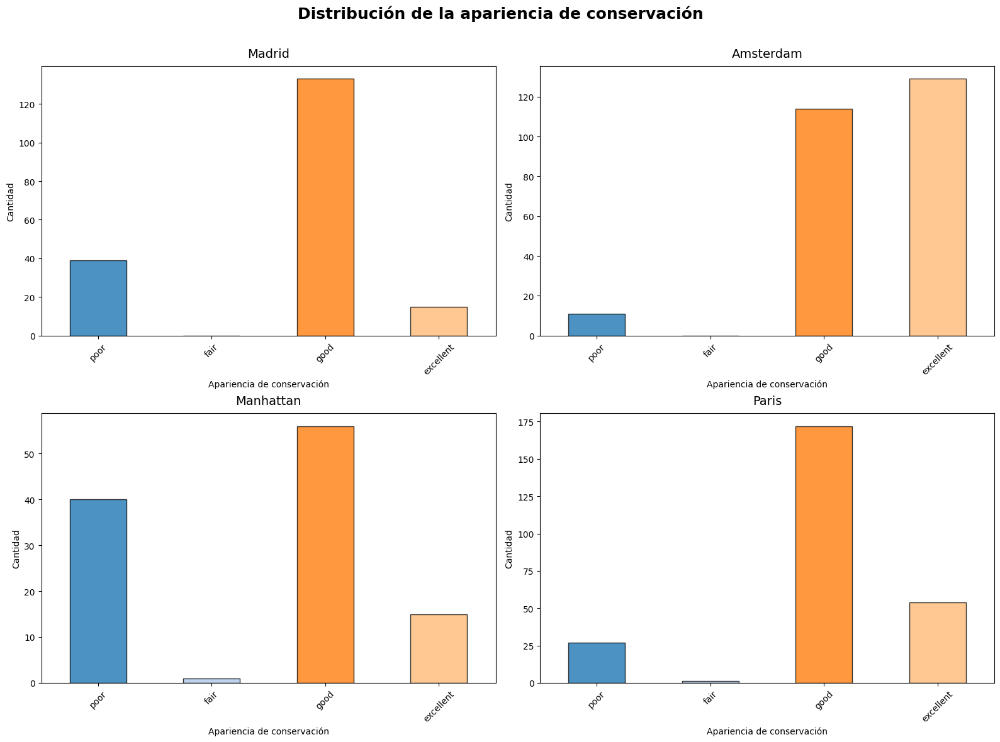

In [ ]:
all_types_madrid = df_madrid['visible_condition']
all_types_amsterdam = df_amsterdam['visible_condition']
all_types_manhattan = df_manhattan['visible_condition']
all_types_paris = df_paris['visible_condition']

counts_madrid = all_types_madrid.value_counts()
counts_amsterdam = all_types_amsterdam.value_counts()
counts_manhattan = all_types_manhattan.value_counts()
counts_paris = all_types_paris.value_counts()

df_counts = pd.DataFrame({
    "Madrid": counts_madrid,
    "Amsterdam": counts_amsterdam,
    "Manhattan": counts_manhattan,
    "Paris": counts_paris
}).fillna(0)

orden_condicion = ['poor', 'fair', 'good', 'excellent']

df_counts = df_counts.reindex(orden_condicion).fillna(0)

categorias = df_counts.index

cmap = plt.get_cmap('tab20')
colores_por_categoria = {categoria: cmap(i % 20) for i, categoria in enumerate(categorias)}

ciudades = ["Madrid", "Amsterdam", "Manhattan", "Paris"]

# crear la figura y los subgráficos
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
fig.suptitle("Distribución de la apariencia de conservación", fontsize=18, fontweight='bold')
axes = axes.flatten()

for i, ciudad in enumerate(ciudades):

    data_ciudad = df_counts[ciudad]

    colores_barras = [colores_por_categoria[cat] for cat in data_ciudad.index]

    data_ciudad.plot(kind='bar', ax=axes[i], color=colores_barras, edgecolor='black', alpha=0.8)

    # configuraciones de cada subgráfico
    axes[i].set_title(f"{ciudad}", fontsize=14, pad=10)
    axes[i].set_xlabel("Apariencia de conservación")
    axes[i].set_ylabel("Cantidad")

    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.subplots_adjust(top=0.90)

plt.show()

#### Proporción de acristalamiento (`glazing_ratio`)

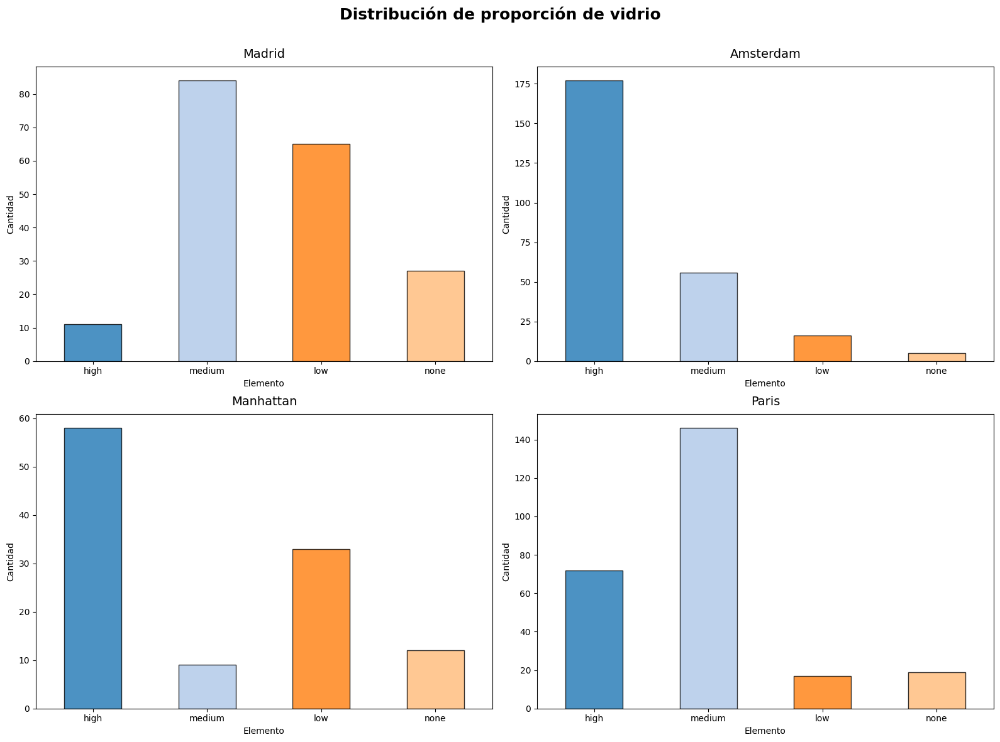

In [ ]:
counts_madrid = df_madrid['glazing_ratio'].value_counts()
counts_amsterdam = df_amsterdam['glazing_ratio'].value_counts()
counts_manhattan = df_manhattan['glazing_ratio'].value_counts()
counts_paris = df_paris['glazing_ratio'].value_counts()

df_counts = pd.DataFrame({
    "Madrid": counts_madrid,
    "Amsterdam": counts_amsterdam,
    "Manhattan": counts_manhattan,
    "Paris": counts_paris
}).fillna(0)

orden_condicion = ['high', 'medium', 'low', 'none']

df_counts = df_counts.reindex(orden_condicion).fillna(0)

categorias = df_counts.index

cmap = plt.get_cmap('tab20')
colores_por_categoria = {categoria: cmap(i % 20) for i, categoria in enumerate(categorias)}

ciudades = ["Madrid", "Amsterdam", "Manhattan", "Paris"]

# crear la figura y los subgráficos
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
fig.suptitle("Distribución de proporción de vidrio", fontsize=18, fontweight='bold')
axes = axes.flatten()

for i, ciudad in enumerate(ciudades):

    data_ciudad = df_counts[ciudad]

    colores_barras = [colores_por_categoria[cat] for cat in data_ciudad.index]

    data_ciudad.plot(kind='bar', ax=axes[i], color=colores_barras, edgecolor='black', alpha=0.8)

    # configuraciones de cada subgráfico
    axes[i].set_title(f"{ciudad}", fontsize=14, pad=10)
    axes[i].set_xlabel("Elemento")
    axes[i].set_ylabel("Cantidad")

    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.subplots_adjust(top=0.90)

plt.show()

### Tercer análisis

In [ ]:
rutas = {
    "Madrid": "/content/drive/MyDrive/Backup_Fachadas/madrid_historico/02_images/individual_building",
    "Paris": "/content/drive/MyDrive/Backup_Fachadas/paris_haussmann/02_images/individual_building",
    "Manhattan": "/content/drive/MyDrive/Backup_Fachadas/ny_manhattan/02_images/individual_building",
    "Amsterdam": "/content/drive/MyDrive/Backup_Fachadas/amsterdam_centro/02_images/individual_building"
}

df_madrid["ciudad"] = "Madrid"
df_paris["ciudad"] = "Paris"
df_manhattan["ciudad"] = "Manhattan"
df_amsterdam["ciudad"] = "Amsterdam"

df_total = pd.concat([df_madrid, df_paris, df_manhattan, df_amsterdam], ignore_index=True)

#### Diagrama de radar:

Madrid

In [ ]:
fila = df_madrid.sample(n=1)

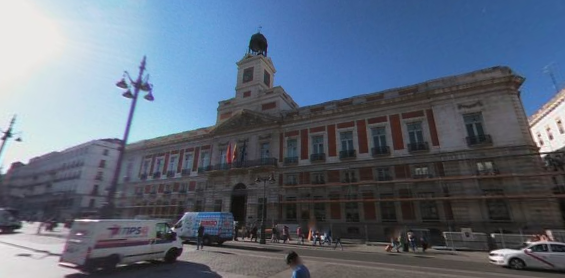

In [ ]:
caracteristicas = ['score_complex', 'score_original', 'score_boring', 'score_ordered', 'score_pleasing']
scores = fila[caracteristicas].iloc[0].values.tolist()

caracteristicas_nombre = ['Complejo', 'Original', 'Aburrido', 'Ordenado', 'Agradable']

nombre = fila['Name'].iloc[0]

carpeta = "/content/drive/MyDrive/Backup_Fachadas/madrid_historico/02_images/individual_building"

ruta = os.path.join(carpeta, nombre)

imagen = Image.open(ruta)

display(imagen)

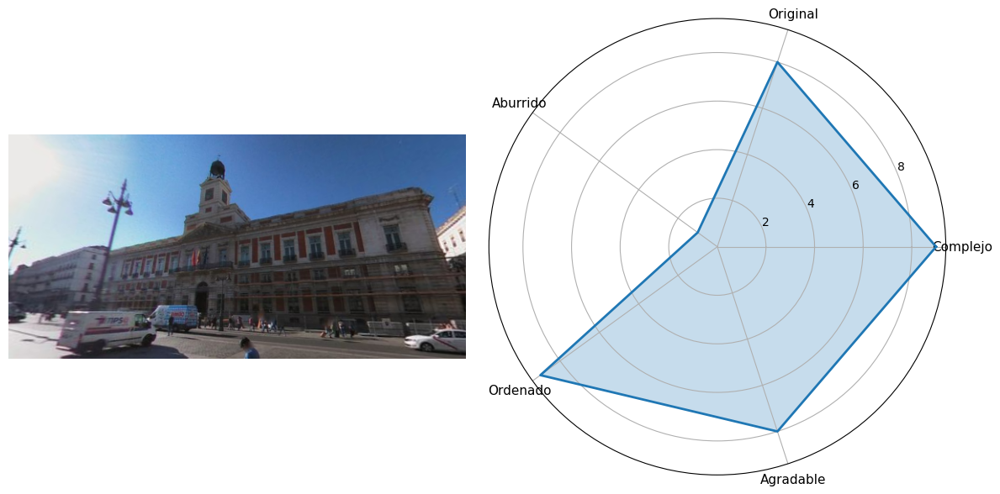

In [ ]:
# Cerrar el radar
scores = scores + [scores[0]]

angulos = np.linspace(0, 2 * np.pi, len(caracteristicas), endpoint=False).tolist()
angulos = angulos + [angulos[0]]

# Crear figura
fig = plt.figure(figsize=(12, 6))

# Imagen
ax_img = fig.add_subplot(1, 2, 1)
ax_img.imshow(imagen)
ax_img.axis('off')

# Radar
ax_radar = fig.add_subplot(1, 2, 2, projection='polar')

ax_radar.plot(angulos, scores, linewidth=2)
ax_radar.fill(angulos, scores, alpha=0.25)

ax_radar.set_xticks(angulos[:-1])
ax_radar.set_xticklabels(caracteristicas_nombre, fontsize=11)

plt.tight_layout()
plt.show()

París

In [ ]:
fila = df_paris.sample(n=1)

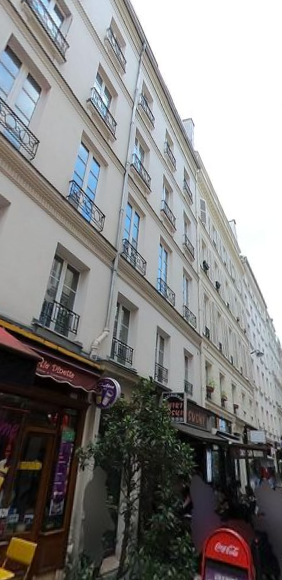

In [ ]:
caracteristicas = ['score_complex', 'score_original', 'score_boring', 'score_ordered', 'score_pleasing']
scores = fila[caracteristicas].iloc[0].values.tolist()

caracteristicas_nombre = ['Complejo', 'Original', 'Aburrido', 'Ordenado', 'Agradable']

nombre = fila['Name'].iloc[0]

carpeta = "/content/drive/MyDrive/Backup_Fachadas/paris_haussmann/02_images/individual_building"

ruta = os.path.join(carpeta, nombre)

imagen = Image.open(ruta)

display(imagen)

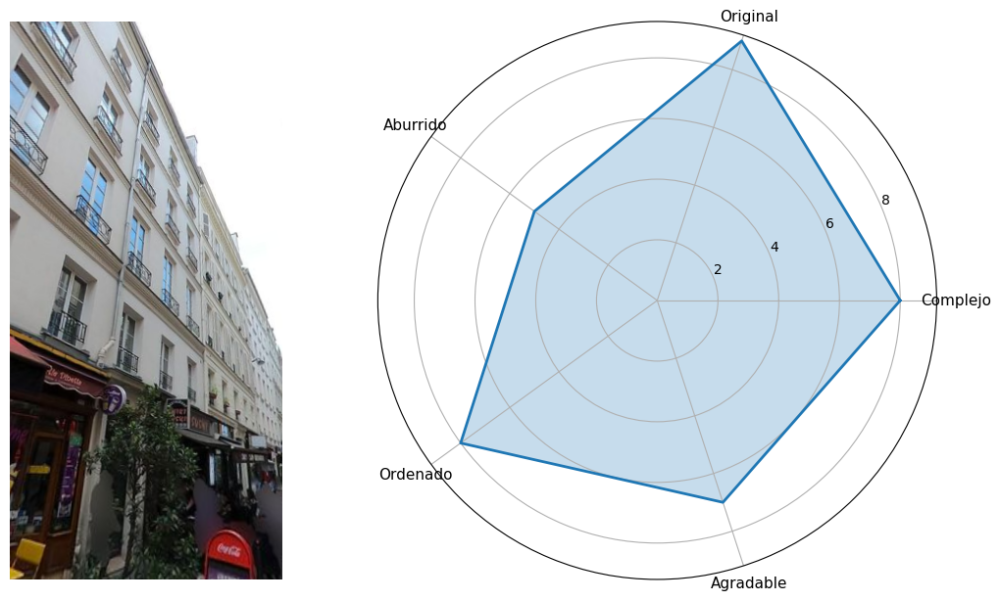

In [ ]:
# Cerrar el radar
scores = scores + [scores[0]]

angulos = np.linspace(0, 2 * np.pi, len(caracteristicas), endpoint=False).tolist()
angulos = angulos + [angulos[0]]

# Crear figura
fig = plt.figure(figsize=(12, 6))

# Imagen
ax_img = fig.add_subplot(1, 2, 1)
ax_img.imshow(imagen)
ax_img.axis('off')

# Radar
ax_radar = fig.add_subplot(1, 2, 2, projection='polar')

ax_radar.plot(angulos, scores, linewidth=2)
ax_radar.fill(angulos, scores, alpha=0.25)

ax_radar.set_xticks(angulos[:-1])
ax_radar.set_xticklabels(caracteristicas_nombre, fontsize=11)

plt.tight_layout()
plt.show()

Manhattan

In [ ]:
fila = df_manhattan.sample(n=1)

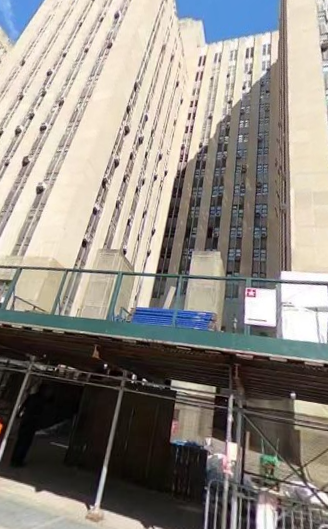

In [ ]:
caracteristicas = ['score_complex', 'score_original', 'score_boring', 'score_ordered', 'score_pleasing']
scores = fila[caracteristicas].iloc[0].values.tolist()

caracteristicas_nombre = ['Complejo', 'Original', 'Aburrido', 'Ordenado', 'Agradable']

nombre = fila['Name'].iloc[0]

carpeta = "/content/drive/MyDrive/Backup_Fachadas/ny_manhattan/02_images/individual_building"

ruta = os.path.join(carpeta, nombre)

imagen = Image.open(ruta)

display(imagen)

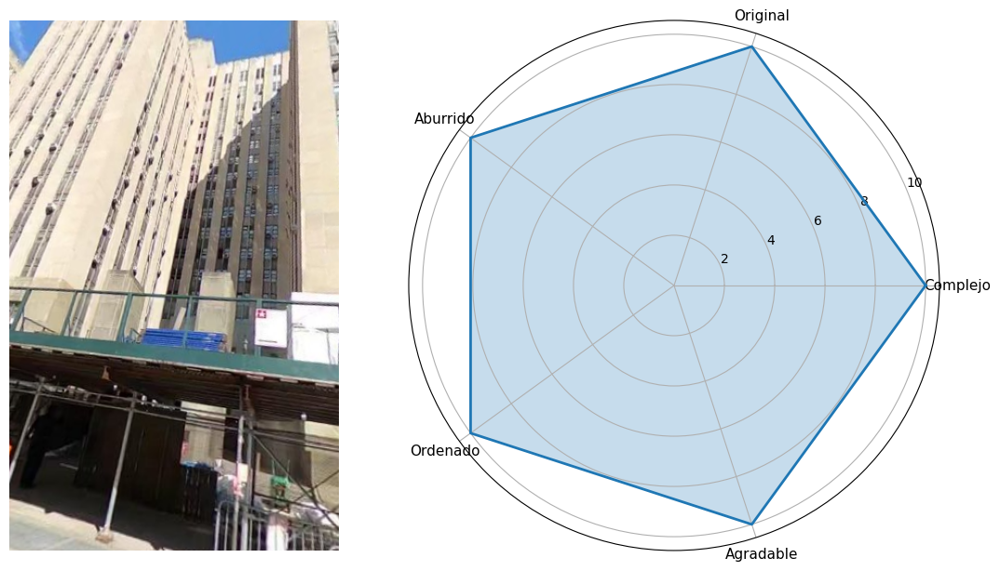

In [ ]:
# Cerrar el radar
scores = scores + [scores[0]]

angulos = np.linspace(0, 2 * np.pi, len(caracteristicas), endpoint=False).tolist()
angulos = angulos + [angulos[0]]

# Crear figura
fig = plt.figure(figsize=(12, 6))

# Imagen
ax_img = fig.add_subplot(1, 2, 1)
ax_img.imshow(imagen)
ax_img.axis('off')

# Radar
ax_radar = fig.add_subplot(1, 2, 2, projection='polar')

ax_radar.plot(angulos, scores, linewidth=2)
ax_radar.fill(angulos, scores, alpha=0.25)

ax_radar.set_xticks(angulos[:-1])
ax_radar.set_xticklabels(caracteristicas_nombre, fontsize=11)

plt.tight_layout()
plt.show()

Ámsterdam

In [ ]:
fila = df_amsterdam.sample(n=1)

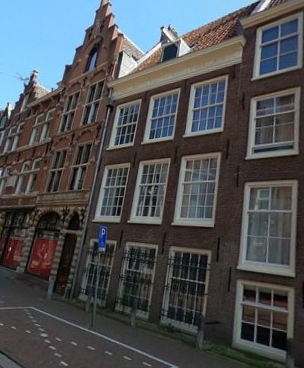

In [ ]:
caracteristicas = ['score_complex', 'score_original', 'score_boring', 'score_ordered', 'score_pleasing']
scores = fila[caracteristicas].iloc[0].values.tolist()

caracteristicas_nombre = ['Complejo', 'Original', 'Aburrido', 'Ordenado', 'Agradable']

nombre = fila['Name'].iloc[0]

carpeta = "/content/drive/MyDrive/Backup_Fachadas/amsterdam_centro/02_images/individual_building"

ruta = os.path.join(carpeta, nombre)

imagen = Image.open(ruta)

display(imagen)

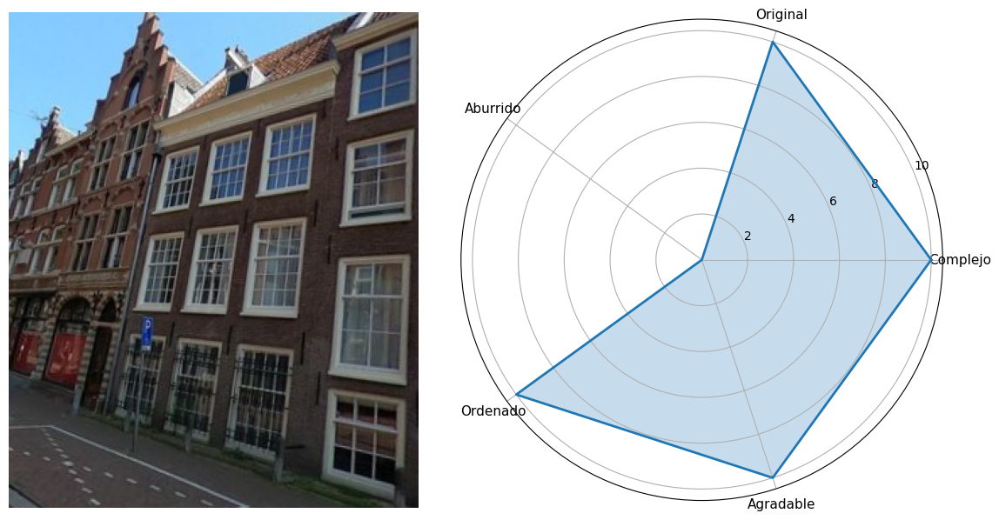

In [ ]:
# Cerrar el radar
scores = scores + [scores[0]]

angulos = np.linspace(0, 2 * np.pi, len(caracteristicas), endpoint=False).tolist()
angulos = angulos + [angulos[0]]

# Crear figura
fig = plt.figure(figsize=(12, 6))

# Imagen
ax_img = fig.add_subplot(1, 2, 1)
ax_img.imshow(imagen)
ax_img.axis('off')

# Radar
ax_radar = fig.add_subplot(1, 2, 2, projection='polar')

ax_radar.plot(angulos, scores, linewidth=2)
ax_radar.fill(angulos, scores, alpha=0.25)

ax_radar.set_xticks(angulos[:-1])
ax_radar.set_xticklabels(caracteristicas_nombre, fontsize=11)

plt.tight_layout()
plt.show()

#### Análisis de los parámetros score

Vamos a ver las fachadas con las puntuaciones más bajas y altas de cada score:

##### Complejo

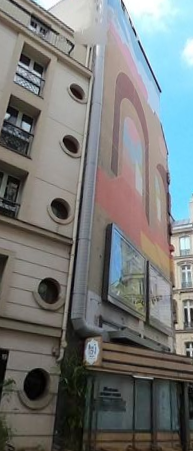

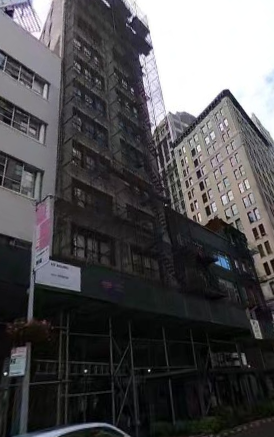

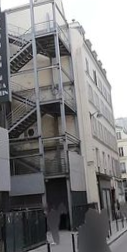

In [ ]:
mascomplejo = df_total[df_total['score_complex'] == 10.0]
mascomplejo = mascomplejo.sample(n=3)

for fila in mascomplejo.itertuples(index=False):
    carpeta = rutas[fila.ciudad]
    nombre = fila.Name

    ruta = os.path.join(carpeta, nombre)

    imagen = Image.open(ruta)
    display(imagen)

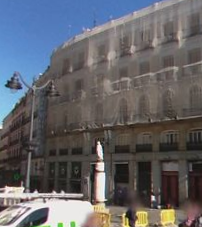

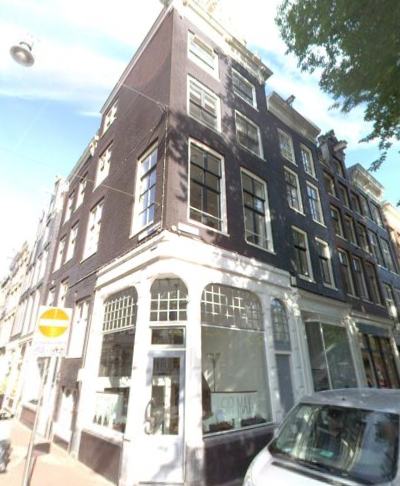

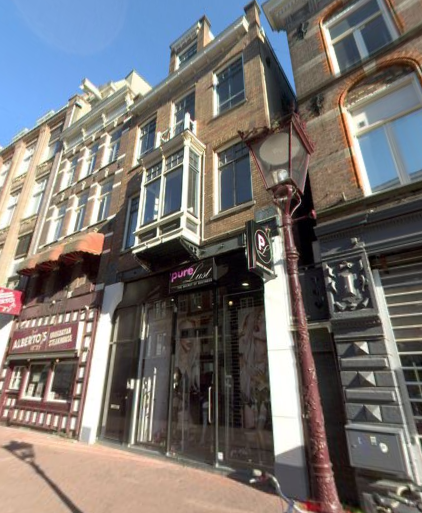

In [ ]:
menoscomplejo = df_total[df_total['score_complex'] == 0.0]
menoscomplejo = menoscomplejo.sample(n=3)

for fila in menoscomplejo.itertuples(index=False):
    carpeta = rutas[fila.ciudad]
    nombre = fila.Name

    ruta = os.path.join(carpeta, nombre)

    imagen = Image.open(ruta)
    display(imagen)

##### Original

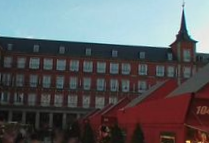

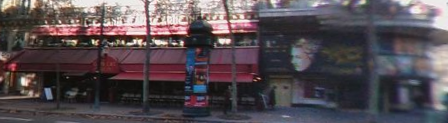

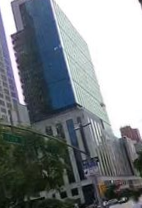

In [ ]:
masoriginal = df_total[df_total['score_original'] == 10.0]
masoriginal = masoriginal.sample(n=3)

for fila in masoriginal.itertuples(index=False):
    carpeta = rutas[fila.ciudad]
    nombre = fila.Name

    ruta = os.path.join(carpeta, nombre)

    imagen = Image.open(ruta)
    display(imagen)

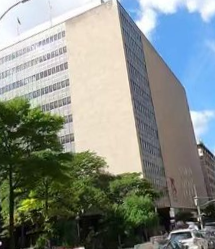

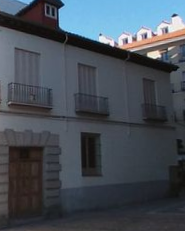

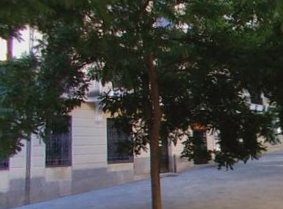

In [ ]:
menosoriginal = df_total[df_total['score_original'] == 0.0]
menosoriginal = menosoriginal.sample(n=3)

for fila in menosoriginal.itertuples(index=False):
    carpeta = rutas[fila.ciudad]
    nombre = fila.Name

    ruta = os.path.join(carpeta, nombre)

    imagen = Image.open(ruta)
    display(imagen)

##### Aburrido

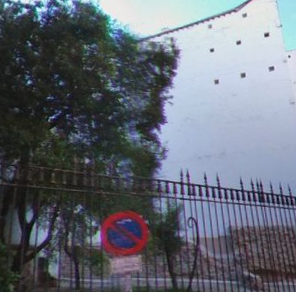

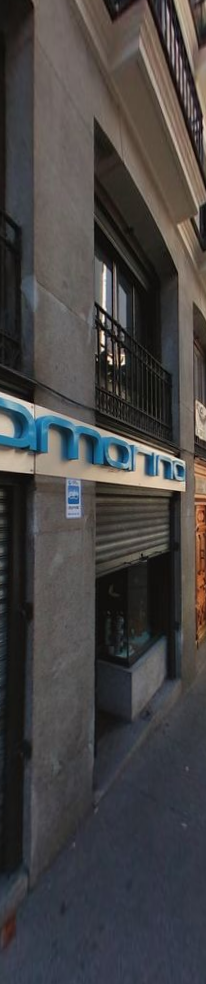

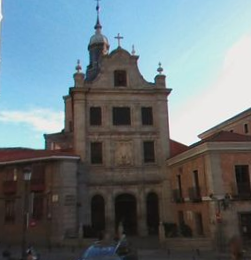

In [ ]:
masaburrido = df_total[df_total['score_boring'] == 10.0]
masaburrido = masaburrido.sample(n=3)

for fila in masaburrido.itertuples(index=False):
    carpeta = rutas[fila.ciudad]
    nombre = fila.Name

    ruta = os.path.join(carpeta, nombre)

    imagen = Image.open(ruta)
    display(imagen)

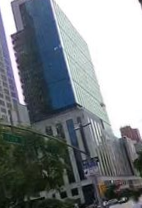

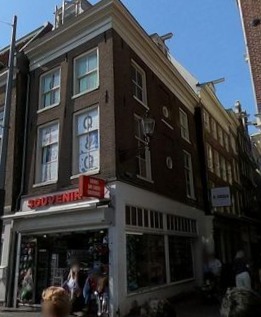

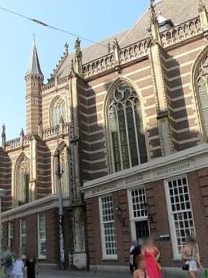

In [ ]:
menosaburrido = df_total[df_total['score_boring'] == 0.0]
menosaburrido = menosaburrido.sample(n=3)

for fila in menosaburrido.itertuples(index=False):
    carpeta = rutas[fila.ciudad]
    nombre = fila.Name

    ruta = os.path.join(carpeta, nombre)

    imagen = Image.open(ruta)
    display(imagen)

##### Ordenado

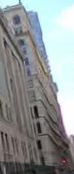

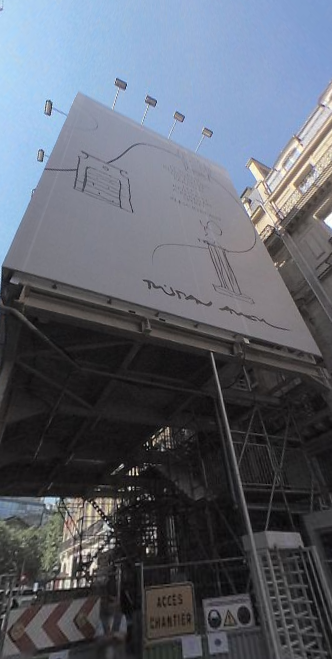

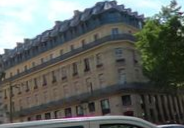

In [ ]:
masordenado = df_total[df_total['score_ordered'] == 10.0]
masordenado = masordenado.sample(n=3)

for fila in masordenado.itertuples(index=False):
    carpeta = rutas[fila.ciudad]
    nombre = fila.Name

    ruta = os.path.join(carpeta, nombre)

    imagen = Image.open(ruta)
    display(imagen)

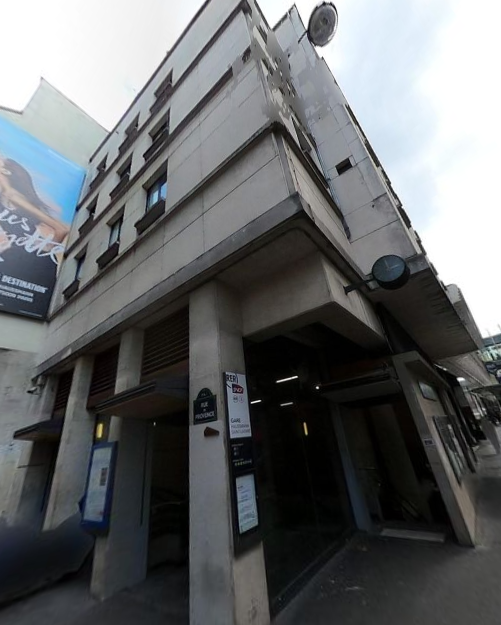

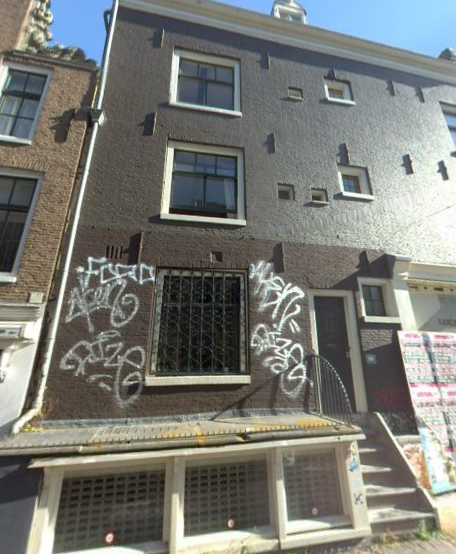

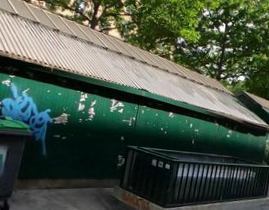

In [ ]:
menosordenado = df_total[df_total['score_ordered'] == 0.0]
menosordenado = menosordenado.sample(n=3)

for fila in menosordenado.itertuples(index=False):
    carpeta = rutas[fila.ciudad]
    nombre = fila.Name

    ruta = os.path.join(carpeta, nombre)

    imagen = Image.open(ruta)
    display(imagen)

##### Agradable

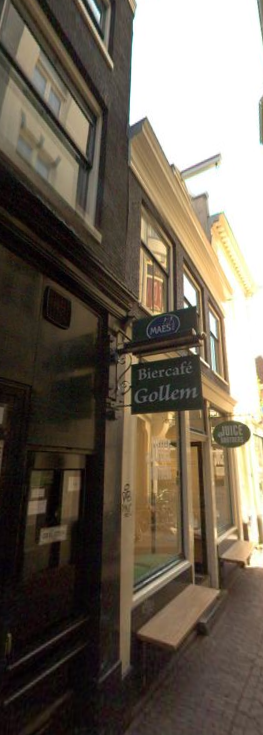

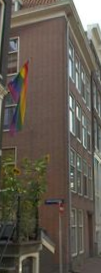

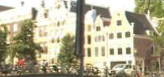

In [ ]:
masagradable = df_total[df_total['score_pleasing'] == 10.0]
masagradable = masagradable.sample(n=3)

for fila in masagradable.itertuples(index=False):
    carpeta = rutas[fila.ciudad]
    nombre = fila.Name

    ruta = os.path.join(carpeta, nombre)

    imagen = Image.open(ruta)
    display(imagen)

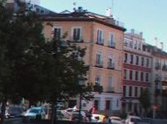

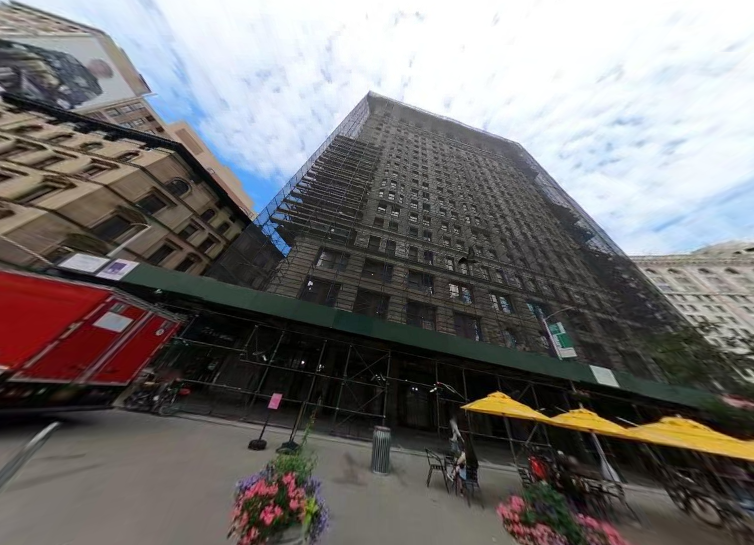

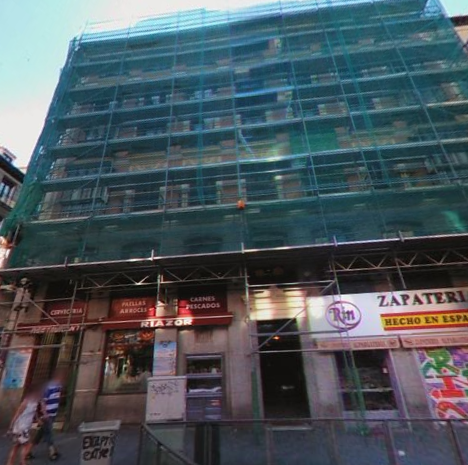

In [ ]:
menosagradable = df_total[df_total['score_pleasing'] == 0.0]
menosagradable = menosagradable.sample(n=3)

for fila in menosagradable.itertuples(index=False):
    carpeta = rutas[fila.ciudad]
    nombre = fila.Name

    ruta = os.path.join(carpeta, nombre)

    imagen = Image.open(ruta)
    display(imagen)

#### Distribución de scores

/tmp/ipykernel_3333/2981217155.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Característica', y='Puntuación', data=df_madrid_melt, palette='Set2')


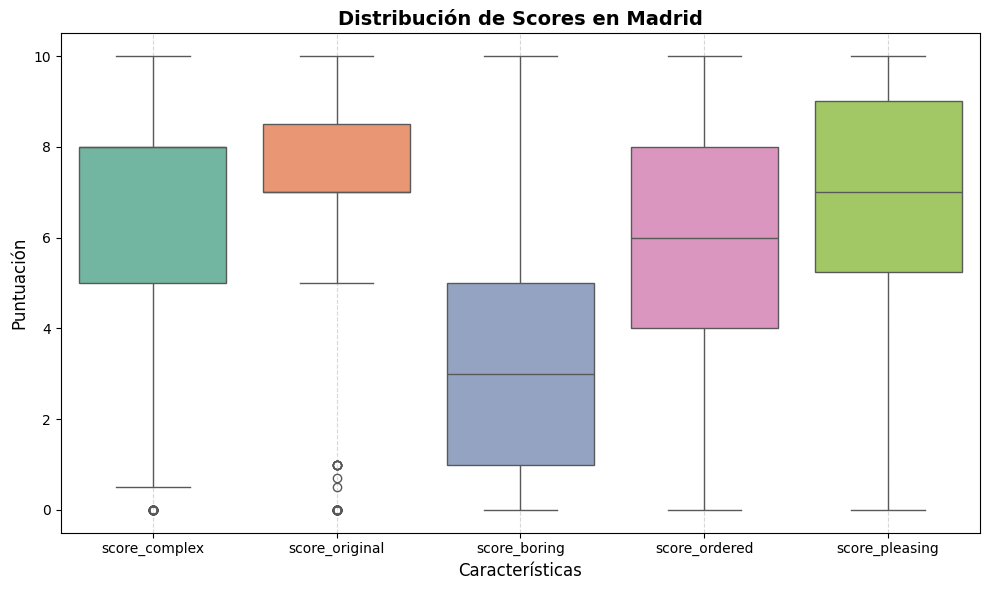

In [ ]:
# Seleccionar solo las columnas de interés
columnas_scores = ['score_complex', 'score_original', 'score_boring', 'score_ordered', 'score_pleasing']
df_madrid_scores = df_madrid[columnas_scores]

# Reestructurar el dataframe para el gráfico (formato largo)
df_madrid_melt = pd.melt(df_madrid_scores, var_name='Característica', value_name='Puntuación')

# Crear el gráfico horizontal
plt.figure(figsize=(10, 6))

# Al poner 'Puntuación' en X y 'Característica' en Y, el boxplot se vuelve horizontal
sns.boxplot(x='Característica', y='Puntuación', data=df_madrid_melt, palette='Set2')

plt.title('Distribución de Scores en Madrid', fontsize=14, fontweight='bold')
plt.xlabel('Características', fontsize=12)
plt.ylabel('Puntuación', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3333/3310878910.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Característica', y='Puntuación', data=df_paris_melt, palette='Set2')


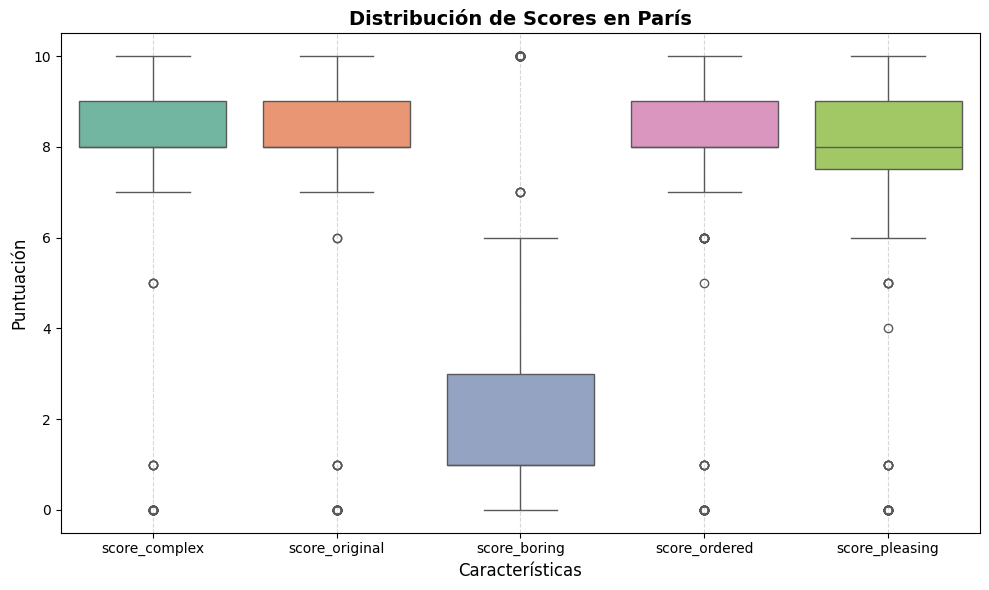

In [ ]:
# Seleccionar solo las columnas de interés
columnas_scores = ['score_complex', 'score_original', 'score_boring', 'score_ordered', 'score_pleasing']
df_paris_scores = df_paris[columnas_scores]

# Reestructurar el dataframe para el gráfico (formato largo)
df_paris_melt = pd.melt(df_paris_scores, var_name='Característica', value_name='Puntuación')

# Crear el gráfico horizontal
plt.figure(figsize=(10, 6))

# Al poner 'Puntuación' en X y 'Característica' en Y, el boxplot se vuelve horizontal
sns.boxplot(x='Característica', y='Puntuación', data=df_paris_melt, palette='Set2')

plt.title('Distribución de Scores en París', fontsize=14, fontweight='bold')
plt.xlabel('Características', fontsize=12)
plt.ylabel('Puntuación', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3333/2209327987.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Característica', y='Puntuación', data=df_manhattan_melt, palette='Set2')


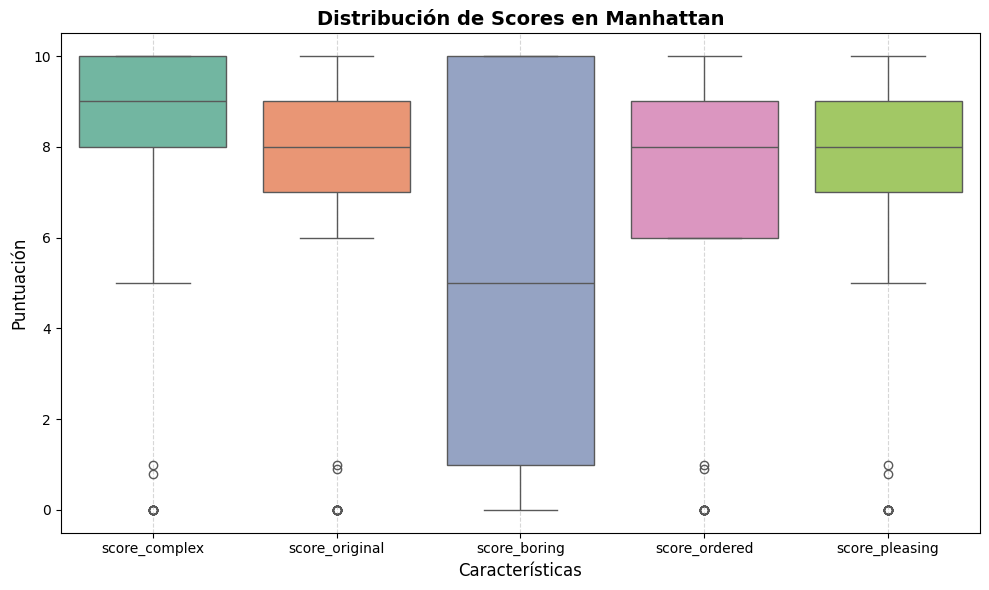

In [ ]:
# Seleccionar solo las columnas de interés
columnas_scores = ['score_complex', 'score_original', 'score_boring', 'score_ordered', 'score_pleasing']
df_manhattan_scores = df_manhattan[columnas_scores]

# Reestructurar el dataframe para el gráfico (formato largo)
df_manhattan_melt = pd.melt(df_manhattan_scores, var_name='Característica', value_name='Puntuación')

# Crear el gráfico horizontal
plt.figure(figsize=(10, 6))

# Al poner 'Puntuación' en X y 'Característica' en Y, el boxplot se vuelve horizontal
sns.boxplot(x='Característica', y='Puntuación', data=df_manhattan_melt, palette='Set2')

plt.title('Distribución de Scores en Manhattan', fontsize=14, fontweight='bold')
plt.xlabel('Características', fontsize=12)
plt.ylabel('Puntuación', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3333/2804458388.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Característica', y='Puntuación', data=df_amsterdam_melt, palette='Set2')


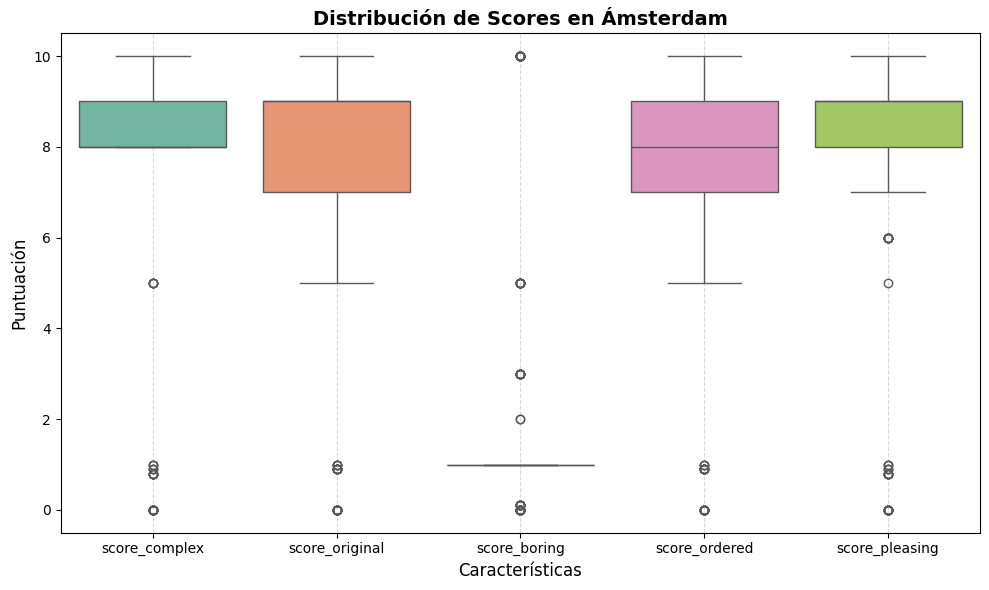

In [ ]:
# Seleccionar solo las columnas de interés
columnas_scores = ['score_complex', 'score_original', 'score_boring', 'score_ordered', 'score_pleasing']
df_amsterdam_scores = df_amsterdam[columnas_scores]

# Reestructurar el dataframe para el gráfico (formato largo)
df_amsterdam_melt = pd.melt(df_amsterdam_scores, var_name='Característica', value_name='Puntuación')

# Crear el gráfico horizontal
plt.figure(figsize=(10, 6))

# Al poner 'Puntuación' en X y 'Característica' en Y, el boxplot se vuelve horizontal
sns.boxplot(x='Característica', y='Puntuación', data=df_amsterdam_melt, palette='Set2')

plt.title('Distribución de Scores en Ámsterdam', fontsize=14, fontweight='bold')
plt.xlabel('Características', fontsize=12)
plt.ylabel('Puntuación', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Matriz de correlación

Matriz de correlación de Madrid:

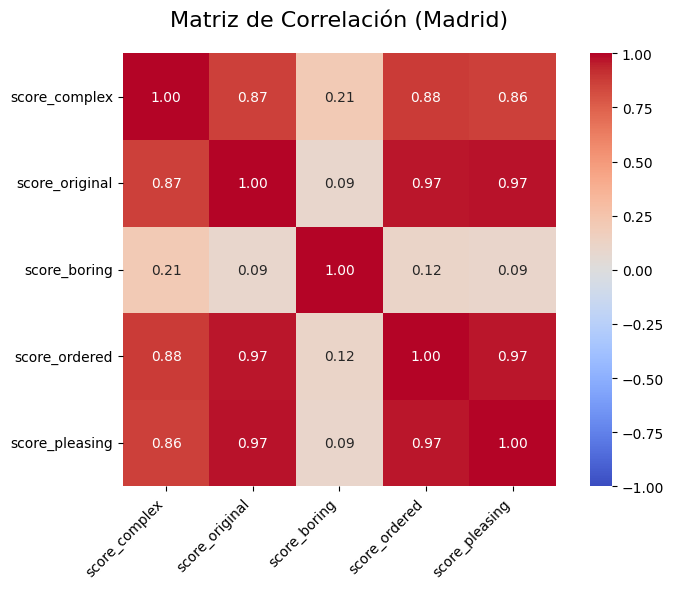

In [ ]:
df = df_madrid[["score_complex", "score_original", "score_boring", "score_ordered", "score_pleasing",]]

corr_matrix = df.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmax=1,
    vmin=-1,
    square=True,
)

plt.title("Matriz de Correlación (Madrid)", fontsize=16, pad=20)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

Matriz de correlación de París:

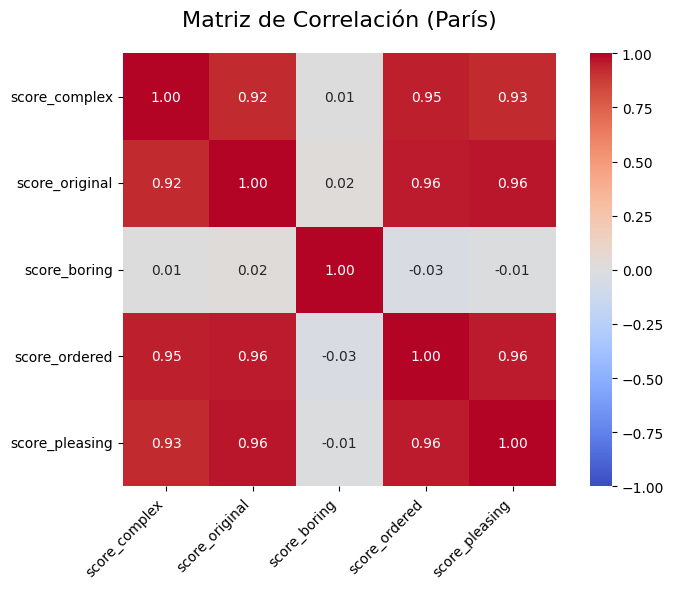

In [ ]:
df = df_paris[["score_complex", "score_original", "score_boring", "score_ordered", "score_pleasing",]]

corr_matrix = df.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmax=1,
    vmin=-1,
    square=True,
)

plt.title("Matriz de Correlación (París)", fontsize=16, pad=20)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

Matriz de correlación de Manhattan:

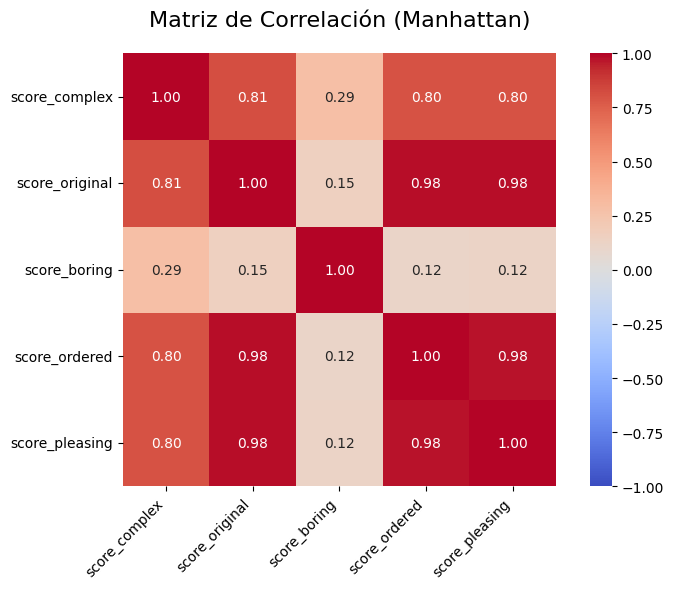

In [ ]:
df = df_manhattan[["score_complex", "score_original", "score_boring", "score_ordered", "score_pleasing",]]

corr_matrix = df.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmax=1,
    vmin=-1,
    square=True,
)

plt.title("Matriz de Correlación (Manhattan)", fontsize=16, pad=20)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

Matriz de correlación de Ámsterdam:

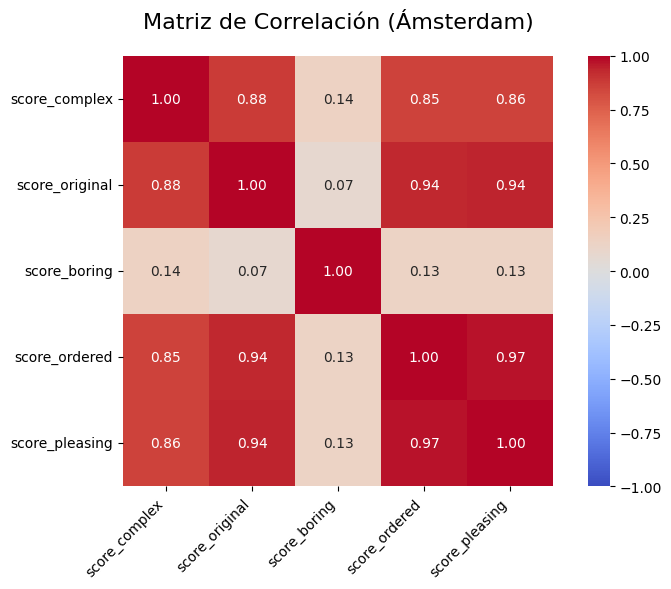

In [ ]:
df = df_amsterdam[["score_complex", "score_original", "score_boring", "score_ordered", "score_pleasing",]]

corr_matrix = df.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmax=1,
    vmin=-1,
    square=True,
)

plt.title("Matriz de Correlación (Ámsterdam)", fontsize=16, pad=20)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [ ]:
print(corr_matrix)

                score_complex  score_original  score_boring  score_ordered  \
score_complex        1.000000        0.878691      0.138942       0.854856   
score_original       0.878691        1.000000      0.071179       0.936122   
score_boring         0.138942        0.071179      1.000000       0.128701   
score_ordered        0.854856        0.936122      0.128701       1.000000   
score_pleasing       0.857171        0.943731      0.125874       0.970371   

                score_pleasing  
score_complex         0.857171  
score_original        0.943731  
score_boring          0.125874  
score_ordered         0.970371  
score_pleasing        1.000000  
